# PPO-SIL Portfolio Evaluation Plots

This notebook loads a trained PPO-SIL portfolio checkpoint (`.pt`) and produces the requested training, average-evaluation, one-path-evaluation, and metric-table outputs.

Evaluation is stochastic: `deterministic=False` is used for the PPO-SIL policy in both the 5000-path evaluation and the averaged one-path diagnostic. The buy-and-hold baseline and PPO-SIL use the same stock-price paths within each evaluation block.

This version reads the FFT calibration Excel files and uses the estimated marginal VG parameters in the stock-price simulation before constructing the evaluation environment.



In [1]:
# User settings
from pathlib import Path
import sys

# Directory containing this notebook, the checkpoint, and SSG_mps.py or SSG.py.
# Change this if those files live elsewhere.
PROJECT_DIR = Path.cwd()

# Checkpoint saved by save_ppo_sil(...). Change the filename if you use best_... or another checkpoint.
CHECKPOINT_PATH = '/Users/goshabor/NTNU/10.Semester/TMA4900 – Industriell matematikk, masteroppgave/Code/Experiment 2 – Dynamic portfolio allocation/SMI/MPS Code/PPO_SIL_pfolio_mps.pt'

# Use None for automatic device selection, or set to "cpu", "mps", or "cuda".
DEVICE_OVERRIDE = None

# Optional ticker names. Leave as None to use Asset 1, Asset 2, ...
# Example: TICKER_NAMES = ["AAPL", "MSFT"]
TICKER_NAMES = None

# Requested evaluation sizes.
N_MC_AVG = 5000
N_T_EVAL = 252
N_MC_ONE_PATH = 1

# Batch size for policy rollouts. Reduce this if GPU/MPS memory is tight.
EVAL_BATCH_SIZE = 5000

# Stochastic policy seed. Stock-path simulation may still use its own generator depending on SSG.py.
EVAL_SEED = 12345

# Output folder for saved figures.
PLOTS_DIR = PROJECT_DIR / 'Plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Make local SSG_mps.py / SSG.py importable and make embedded code behave like a normal .py file.
PROJECT_DIR = Path(PROJECT_DIR).expanduser().resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
__file__ = str(PROJECT_DIR / "ppo_sil_evaluation_notebook_embedded.py")

print(f"PROJECT_DIR      = {PROJECT_DIR}")
print(f"CHECKPOINT_PATH  = {CHECKPOINT_PATH}")
print(f"PLOTS_DIR        = {PLOTS_DIR}")

PROJECT_DIR      = /Users/goshabor/NTNU/10.Semester/TMA4900 – Industriell matematikk, masteroppgave/Code/Experiment 2 – Dynamic portfolio allocation/SMI/MPS Code
CHECKPOINT_PATH  = /Users/goshabor/NTNU/10.Semester/TMA4900 – Industriell matematikk, masteroppgave/Code/Experiment 2 – Dynamic portfolio allocation/SMI/MPS Code/PPO_SIL_pfolio_mps.pt
PLOTS_DIR        = /Users/goshabor/NTNU/10.Semester/TMA4900 – Industriell matematikk, masteroppgave/Code/Experiment 2 – Dynamic portfolio allocation/SMI/MPS Code/Plots


## Embedded PPO-SIL model and environment code

The next cell embeds the relevant PPO-SIL portfolio code inside the notebook so no separate evaluation `.py` file is needed. It still expects `SSG_mps.py` or `SSG.py` to be importable from `PROJECT_DIR` because your environment uses that simulator for stock paths.

In [2]:
from __future__ import annotations

import importlib.util
import math
import os
import random
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn


# ---------------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------------


def set_seed(seed: int) -> None:
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


def get_device(device: Optional[str] = None) -> torch.device:
    if device is not None:
        return torch.device(device)
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def activation_module(name: str) -> nn.Module:
    name = str(name).lower()
    if name == "relu":
        return nn.ReLU()
    if name == "gelu":
        return nn.GELU()
    if name == "elu":
        return nn.ELU()
    if name == "silu" or name == "swish":
        return nn.SiLU()
    if name == "sigmoid":
        return nn.Sigmoid()
    if name == "tanh":
        return nn.Tanh()
    raise ValueError(f"Unknown activation {name!r}.")


def orthogonal_init_(module: nn.Module, gain: float = math.sqrt(2.0)) -> None:
    if isinstance(module, nn.Linear):
        nn.init.orthogonal_(module.weight, gain=gain)
        nn.init.zeros_(module.bias)


def _as_float_list(x: float | Iterable[float], d: int, name: str) -> List[float]:
    if isinstance(x, (float, int)):
        return [float(x)] * int(d)
    out = [float(v) for v in x]
    if len(out) != int(d):
        raise ValueError(f"{name} must have length d={d}; got length {len(out)}.")
    return out


def _as_float_matrix(
    x: Optional[float | Iterable[float] | Iterable[Iterable[float]]],
    d: int,
    name: str,
    *,
    default_zero: bool = True,
) -> List[List[float]]:
    """Return a d x d float matrix.

    Scalars and length-one vectors are interpreted as diagonal matrices with
    constant diagonal.  Length-d vectors are interpreted as diagonal matrices.
    """
    if x is None:
        arr = np.zeros((int(d), int(d)), dtype=float) if default_zero else np.eye(int(d), dtype=float)
    else:
        arr = np.asarray(x, dtype=float)
        if arr.ndim == 0:
            arr = np.eye(int(d), dtype=float) * float(arr)
        elif arr.ndim == 1:
            if arr.size == 1:
                arr = np.eye(int(d), dtype=float) * float(arr.item())
            elif arr.size == int(d):
                arr = np.diag(arr.astype(float))
            else:
                raise ValueError(f"{name} vector must have length 1 or d={d}; got length {arr.size}.")
        elif arr.ndim == 2:
            if arr.shape != (int(d), int(d)):
                raise ValueError(f"{name} must have shape ({d},{d}); got {arr.shape}.")
        else:
            raise ValueError(f"{name} must be scalar, vector, or matrix.")
    if not np.isfinite(arr).all():
        raise ValueError(f"{name} contains non-finite values.")
    return arr.astype(float).tolist()


def _finite_or_raise(name: str, x: torch.Tensor) -> None:
    if not torch.isfinite(x).all():
        bad = x[~torch.isfinite(x)]
        sample = bad[:5].detach().cpu().numpy() if bad.numel() else []
        raise FloatingPointError(f"{name} contains non-finite values; sample={sample}")


def _clear_device_cache(device: torch.device) -> None:
    if device.type == "mps" and hasattr(torch, "mps"):
        try:
            torch.mps.empty_cache()
        except Exception:
            pass
    elif device.type == "cuda":
        torch.cuda.empty_cache()


# ---------------------------------------------------------------------------
# Configs
# ---------------------------------------------------------------------------


@dataclass
class MarketConfig:
    # Market dimension and horizon.
    d: int = 2
    T: float = 1.0
    n_steps: int = 252
    r: float = 0.04

    # Drift and initial portfolio.
    mu: List[float] = field(default_factory=lambda: [-0.10, 0.20])
    s0: List[float] = field(default_factory=lambda: [100.0, 100.0])
    h0: List[float] = field(default_factory=lambda: [100.0, 100.0])
    cash0: float = 10_000.0

    # Revised SSG rho-alpha VG inputs.
    sigma: List[float] = field(default_factory=lambda: [0.15, 0.15])
    theta: List[float] = field(default_factory=lambda: [0.0, 0.0])
    nu: List[float] = field(default_factory=lambda: [0.20, 0.20])
    log_returns_corr_matrix: Optional[List[List[float]] | List[float] | float] = None

    # Stock-price simulation control.  ``ssg_seed`` is kept only so older
    # checkpoints/notebooks still instantiate; it is not used by the simulator.
    ssg_seed: Optional[int] = None
    ssg_path_mean_samples: int = 10
    ssg_max_simulated_paths_per_chunk: int = 8192

    # Legacy fields accepted for backward compatibility with older notebooks /
    # checkpoints.  They are not used by the revised SSG adapter.
    vg_C: Optional[List[float]] = None
    vg_G: Optional[List[float]] = None
    vg_M: Optional[List[float]] = None
    ssg_sigma_mat: Optional[List[List[float]] | List[float] | float] = None
    ssg_scale_to_T: bool = False
    ssg_generate_on_cpu: bool = False
    vg_drift_mode: str = "martingale"
    gamma_on_cpu: bool = True
    vg_corr_matrix: Optional[List[List[float]]] = None

    # Transaction costs.  fixed_cost is charged once per non-zero impulse, not
    # once per asset, so simultaneous multi-asset trades are allowed.
    fixed_cost: float = 29.0
    proportional_cost: float = 0.001

    # Continuous action constraints in shares.
    max_holding: float | List[float] = 200.0
    min_holding: float | List[float] = 0.0
    max_trade_size: float | List[float] = 200.0
    allow_negative_cash: bool = False
    self_financing: bool = True

    # Initial-state randomisation.  All are off by default to reproduce the
    # original example's deterministic initial portfolio.
    randomize_initial_prices: bool = False
    randomize_initial_holdings: bool = False
    randomize_initial_cash: bool = False
    initial_price_log_std: float = 0.02
    initial_holding_noise: float = 0.0
    initial_cash_noise: float = 0.0

    # Reward scaling only changes numerical conditioning; it does not change
    # the maximiser of expected discounted terminal wealth.
    reward_scale: float = 1.0e-3

    # Numerical safeguards.
    min_price: float = 1.0e-8
    max_price: float = 1.0e8

    def __post_init__(self) -> None:
        self.d = int(self.d)
        if self.d < 1:
            raise ValueError("d must be positive.")
        if self.T <= 0 or self.n_steps < 1:
            raise ValueError("T must be positive and n_steps must be at least 1.")
        self.mu = _as_float_list(self.mu, self.d, "mu")
        self.s0 = _as_float_list(self.s0, self.d, "s0")
        self.h0 = _as_float_list(self.h0, self.d, "h0")
        self.sigma = _as_float_list(self.sigma, self.d, "sigma")
        self.theta = _as_float_list(self.theta, self.d, "theta")
        self.nu = _as_float_list(self.nu, self.d, "nu")
        self.log_returns_corr_matrix = _as_float_matrix(
            self.log_returns_corr_matrix,
            self.d,
            "log_returns_corr_matrix",
            default_zero=False,
        )
        self.max_holding = _as_float_list(self.max_holding, self.d, "max_holding")
        self.min_holding = _as_float_list(self.min_holding, self.d, "min_holding")
        self.max_trade_size = _as_float_list(self.max_trade_size, self.d, "max_trade_size")
        self.ssg_path_mean_samples = max(1, int(self.ssg_path_mean_samples))
        self.ssg_max_simulated_paths_per_chunk = max(1, int(self.ssg_max_simulated_paths_per_chunk))

        if any(s <= 0.0 for s in self.sigma):
            raise ValueError("SSG sigma entries must be strictly positive.")
        if any(n <= 0.0 for n in self.nu):
            raise ValueError("SSG nu entries must be strictly positive.")
        log_args = [
            1.0 - th * nu_i - 0.5 * sig * sig * nu_i
            for sig, th, nu_i in zip(self.sigma, self.theta, self.nu)
        ]
        if any(x <= 0.0 for x in log_args):
            raise ValueError(
                "Invalid SSG parameters: every 1 - theta_i * nu_i - 0.5 * sigma_i^2 * nu_i must be positive."
            )

        corr = np.asarray(self.log_returns_corr_matrix, dtype=float)
        if corr.shape != (self.d, self.d):
            raise ValueError(f"log_returns_corr_matrix must have shape ({self.d},{self.d}); got {corr.shape}.")
        if not np.isfinite(corr).all():
            raise ValueError("log_returns_corr_matrix contains non-finite values.")
        if not np.allclose(corr, corr.T, atol=1e-8):
            raise ValueError("log_returns_corr_matrix must be symmetric.")
        if np.any(np.diag(corr) <= 0.0):
            raise ValueError("log_returns_corr_matrix diagonal entries must be positive.")

        if self.vg_corr_matrix is not None:
            arr = np.asarray(self.vg_corr_matrix, dtype=float)
            if arr.shape != (self.d, self.d):
                raise ValueError("vg_corr_matrix must have shape (d,d).")


@dataclass
class PPOSILConfig:
    seed: int = 42
    device: Optional[str] = None
    dtype: str = "float32"

    train_iters: int = 500
    rollout_envs: int = 512
    gamma_rl: float = 1.0
    gae_lambda: float = 1.0

    ppo_epochs: int = 5
    minibatch_size: int = 4096
    lr: float = 3.0e-4
    weight_decay: float = 0.0
    clip_eps: float = 0.20
    value_coef: float = 0.50
    entropy_coef: float = 1.0e-3
    target_kl: float = 0.05
    max_grad_norm: float = 1.0
    advantage_eps: float = 1.0e-8

    # Two-network architecture.
    hidden_dims: Tuple[int, ...] = (512, 512, 128)
    activation: str = "tanh"
    layer_norm: bool = False
    decision_bias: float = -1.0
    init_log_std: float = -0.35
    min_log_std: float = -3.0
    max_log_std: float = 1.0

    # SIL replay and losses.
    use_sil: bool = True
    sil_buffer_capacity: int = 200_000
    sil_batch_size: int = 4096
    sil_updates_per_iter: int = 1
    sil_warmup_iters: int = 2
    sil_priority_alpha: float = 0.7
    sil_priority_eps: float = 1.0e-6
    sil_margin: float = 0.0
    sil_decision_policy_coef: float = 0.05
    sil_decision_value_coef: float = 0.05
    sil_impulse_policy_coef: float = 0.05
    sil_impulse_value_coef: float = 0.05
    keep_sil_on_cpu: bool = True

    # Evaluation / logging.
    eval_envs: int = 1024
    eval_every: int = 10
    eval_batch_size: int = 256
    eval_deterministic: bool = False
    log_every: int = 1
    checkpoint_path: str = "PPO_SIL_pfolio.pt"
    clear_cache: bool = True


# ---------------------------------------------------------------------------
# SSG-driven vectorised portfolio environment
# ---------------------------------------------------------------------------


_SSG_MODULE_CANDIDATES = ("SSG_mps", "SSG")


def _import_ssg_module() -> Any:
    """Import the SSG module without requiring a package layout."""
    first_error: Optional[BaseException] = None
    for module_name in _SSG_MODULE_CANDIDATES:
        try:
            return __import__(module_name)  # type: ignore[no-any-return]
        except Exception as exc:
            if first_error is None:
                first_error = exc

    local_candidates = [Path(__file__).with_name(f"{name}.py") for name in _SSG_MODULE_CANDIDATES]
    for local_path in local_candidates:
        if not local_path.exists():
            continue
        spec = importlib.util.spec_from_file_location(local_path.stem, str(local_path))
        if spec is None or spec.loader is None:
            continue
        module = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(module)
        return module

    raise ImportError(
        "Could not import an SSG module. Put SSG_mps.py or SSG.py in the same directory "
        "as this PPO_SIL_pfolio file, or make it importable on PYTHONPATH."
    ) from first_error


SSG = _import_ssg_module()


def _make_ssg_simulator(
    *,
    S0_vec: Iterable[float],
    mu_vec: Iterable[float],
    sigma_vec: Iterable[float],
    theta_vec: Iterable[float],
    nu_vec: Iterable[float],
    log_returns_corr_matrix: Iterable[Iterable[float]],
    T: float,
    N_t: int,
    N_MC: int,
    device: torch.device,
    dtype: torch.dtype,
    path_mean_samples: int,
    max_simulated_paths_per_chunk: int,
) -> Any:
    """Construct the revised ``SSG.SSG`` simulator once."""
    cls = getattr(SSG, "SSG", None)
    if cls is None:
        raise ImportError("The imported SSG module does not expose an SSG class.")

    S0 = np.asarray(S0_vec, dtype=float).reshape(-1)
    mu = np.asarray(mu_vec, dtype=float).reshape(-1)
    sigma = np.asarray(sigma_vec, dtype=float).reshape(-1)
    theta = np.asarray(theta_vec, dtype=float).reshape(-1)
    nu = np.asarray(nu_vec, dtype=float).reshape(-1)
    corr = np.asarray(log_returns_corr_matrix, dtype=float)

    d = int(S0.size)
    for name, arr in {"mu_vec": mu, "sigma_vec": sigma, "theta_vec": theta, "nu_vec": nu}.items():
        if arr.size != d:
            raise ValueError(f"{name} must have length d={d}; got length {arr.size}.")
    if corr.shape != (d, d):
        raise ValueError(f"log_returns_corr_matrix must have shape ({d},{d}); got {corr.shape}.")

    return cls(
        S0_vec=S0,
        mu_vec=mu,
        sigma_vec=sigma,
        theta_vec=theta,
        nu_vec=nu,
        log_returns_corr_matrix=corr,
        T=float(T),
        N_t=int(N_t),
        N_MC=int(N_MC),
        device=device,
        dtype=dtype,
        seed=None,
        return_torch=True,
        path_mean_samples=int(path_mean_samples),
        max_simulated_paths_per_chunk=int(max_simulated_paths_per_chunk),
    )


class VarianceGammaPortfolioEnv:
    """Vectorised impulse-control environment using SSG.py for stock paths.

    One ``SSG.SSG`` instance is initialised in ``__init__`` and reused for all
    rollouts/evaluations.  The stock-price simulator itself is not seeded; it
    uses entropy-initialised torch generators, so the price paths are not tied
    to the PPO seed.
    """

    def __init__(self, cfg: MarketConfig, device: torch.device, dtype: torch.dtype = torch.float32) -> None:
        self.cfg = cfg
        self.device = device
        self.dtype = dtype
        self.d = int(cfg.d)
        self.dt = float(cfg.T) / int(cfg.n_steps)
        self.obs_dim = 4 + 3 * self.d
        self.action_dim = self.d

        self.mu = torch.tensor(cfg.mu, device=device, dtype=dtype)
        self.s0 = torch.tensor(cfg.s0, device=device, dtype=dtype)
        self.h0 = torch.tensor(cfg.h0, device=device, dtype=dtype)
        self.max_holding = torch.tensor(cfg.max_holding, device=device, dtype=dtype)
        self.min_holding = torch.tensor(cfg.min_holding, device=device, dtype=dtype)
        self.max_trade_size = torch.tensor(cfg.max_trade_size, device=device, dtype=dtype)
        self.sigma = torch.tensor(cfg.sigma, device=device, dtype=dtype)
        self.theta = torch.tensor(cfg.theta, device=device, dtype=dtype)
        self.nu = torch.tensor(cfg.nu, device=device, dtype=dtype)
        self.log_returns_corr_matrix = torch.tensor(cfg.log_returns_corr_matrix, device=device, dtype=dtype)
        self.cash_scale = max(float(cfg.cash0), 1.0)
        self.wealth_scale = max(float(cfg.cash0 + float(torch.sum(self.h0 * self.s0).detach().cpu())), 1.0)

        s0_np, mu_np, sigma_np, theta_np, nu_np, corr_np = self._ssg_inputs()
        self._ssg_simulator = _make_ssg_simulator(
            S0_vec=s0_np,
            mu_vec=mu_np,
            sigma_vec=sigma_np,
            theta_vec=theta_np,
            nu_vec=nu_np,
            log_returns_corr_matrix=corr_np,
            T=float(self.cfg.T),
            N_t=int(self.cfg.n_steps),
            N_MC=1,
            device=self.device,
            dtype=self.dtype,
            path_mean_samples=int(self.cfg.ssg_path_mean_samples),
            max_simulated_paths_per_chunk=int(self.cfg.ssg_max_simulated_paths_per_chunk),
        )

    def _ssg_inputs(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Return the revised SSG inputs as NumPy arrays."""
        s0 = np.asarray(self.cfg.s0, dtype=float)
        mu = np.asarray(self.cfg.mu, dtype=float)
        sigma = np.asarray(self.cfg.sigma, dtype=float)
        theta = np.asarray(self.cfg.theta, dtype=float)
        nu = np.asarray(self.cfg.nu, dtype=float)
        corr = np.asarray(self.cfg.log_returns_corr_matrix, dtype=float)
        return s0, mu, sigma, theta, nu, corr

    @torch.no_grad()
    def sample_price_paths(self, n_envs: int, seed: Optional[int] = None) -> torch.Tensor:
        """Generate SSG stock paths with shape ``(n_envs, n_steps + 1, d)``.

        The ``seed`` argument is ignored intentionally: stock-price paths should
        remain genuinely random across rollouts.
        """
        _ = seed
        n_envs = int(n_envs)
        self._ssg_simulator.N_MC = n_envs
        paths_raw = self._ssg_simulator.simulate_stock_price_process(
            N_MC=n_envs,
            mean_samples=int(self.cfg.ssg_path_mean_samples),
            return_torch=True,
        )
        if isinstance(paths_raw, torch.Tensor):
            paths = paths_raw.to(device=self.device, dtype=self.dtype)
        else:
            paths = torch.as_tensor(paths_raw, device=self.device, dtype=self.dtype)
        if tuple(paths.shape) != (n_envs, int(self.cfg.n_steps) + 1, self.d):
            raise RuntimeError(
                f"SSG returned paths with shape {tuple(paths.shape)}, expected "
                f"({n_envs}, {int(self.cfg.n_steps) + 1}, {self.d})."
            )
        return paths.clamp(float(self.cfg.min_price), float(self.cfg.max_price))

    def reset(self, n_envs: int, price_paths: Optional[torch.Tensor] = None) -> Dict[str, torch.Tensor]:
        n_envs = int(n_envs)
        if price_paths is None:
            price_paths = self.sample_price_paths(n_envs)
        else:
            price_paths = price_paths.to(device=self.device, dtype=self.dtype)
            expected = (n_envs, int(self.cfg.n_steps) + 1, self.d)
            if tuple(price_paths.shape) != expected:
                raise ValueError(f"price_paths must have shape {expected}; got {tuple(price_paths.shape)}.")
            price_paths = price_paths.clamp(float(self.cfg.min_price), float(self.cfg.max_price))

        if self.cfg.randomize_initial_prices:
            eps = torch.randn((n_envs, self.d), device=self.device, dtype=self.dtype) * float(self.cfg.initial_price_log_std)
            price_paths = price_paths * torch.exp(eps).unsqueeze(1)
            price_paths = price_paths.clamp(float(self.cfg.min_price), float(self.cfg.max_price))

        s = price_paths[:, 0, :]
        h = self.h0.unsqueeze(0).repeat(n_envs, 1)
        cash = torch.full((n_envs,), float(self.cfg.cash0), device=self.device, dtype=self.dtype)

        if self.cfg.randomize_initial_holdings and self.cfg.initial_holding_noise > 0:
            h = h + torch.randn_like(h) * float(self.cfg.initial_holding_noise)
            h = h.clamp(self.min_holding, self.max_holding)
        if self.cfg.randomize_initial_cash and self.cfg.initial_cash_noise > 0:
            cash = cash + torch.randn_like(cash) * float(self.cfg.initial_cash_noise)
            if not self.cfg.allow_negative_cash:
                cash = cash.clamp_min(0.0)

        return {
            "s": s,
            "h": h,
            "cash": cash,
            "step": torch.zeros(n_envs, device=self.device, dtype=torch.long),
            "price_path": price_paths,
        }

    def time(self, state: Dict[str, torch.Tensor]) -> torch.Tensor:
        return state["step"].to(self.dtype) * self.dt

    def wealth(self, state: Dict[str, torch.Tensor]) -> torch.Tensor:
        return state["cash"] + (state["h"] * state["s"]).sum(dim=-1)

    def discounted_wealth(self, state: Dict[str, torch.Tensor]) -> torch.Tensor:
        return torch.exp(-float(self.cfg.r) * self.time(state)) * self.wealth(state)

    def observe(self, state: Dict[str, torch.Tensor]) -> torch.Tensor:
        s = state["s"]
        h = state["h"]
        cash = state["cash"]
        step = state["step"].to(self.dtype)
        t_frac = step / float(self.cfg.n_steps)
        wealth = self.wealth(state).clamp_min(1.0e-8)
        log_prices = torch.log((s / self.s0).clamp_min(1.0e-12)).clamp(-10.0, 10.0)
        h_scaled = h / self.max_holding.clamp_min(1.0)
        risky_weights = (h * s) / wealth.unsqueeze(-1)
        return torch.cat(
            [
                t_frac.unsqueeze(-1),
                (1.0 - t_frac).unsqueeze(-1),
                (cash / self.cash_scale).unsqueeze(-1),
                (wealth / self.wealth_scale).unsqueeze(-1),
                log_prices,
                h_scaled,
                risky_weights,
            ],
            dim=-1,
        )

    def sample_vg_log_increment(self, n_envs: int) -> torch.Tensor:
        """Backward-compatible one-step increment sampler, generated through SSG."""
        paths = self.sample_price_paths(int(n_envs))
        return torch.log((paths[:, 1, :] / paths[:, 0, :]).clamp_min(1.0e-12))

    def _transaction_cost(self, s: torch.Tensor, trade: torch.Tensor) -> torch.Tensor:
        notional = (trade.abs() * s).sum(dim=-1)
        has_trade = (trade.abs().sum(dim=-1) > 1.0e-8).to(self.dtype)
        return float(self.cfg.fixed_cost) * has_trade + float(self.cfg.proportional_cost) * notional

    def project_trade(self, state: Dict[str, torch.Tensor], desired_trade: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Project continuous trade vector to holdings/cash constraints."""
        s = state["s"]
        h = state["h"]
        cash = state["cash"]
        trade = desired_trade.clamp(-self.max_trade_size, self.max_trade_size)
        trade = torch.minimum(trade, self.max_holding - h)
        trade = torch.maximum(trade, self.min_holding - h)

        if self.cfg.self_financing and not self.cfg.allow_negative_cash:
            cost = self._transaction_cost(s, trade)
            new_cash = cash - (trade * s).sum(dim=-1) - cost
            bad = new_cash < -1.0e-6
            if bad.any():
                # Keep sells, scale buys to fit the post-sell cash budget.
                buys = trade.clamp_min(0.0)
                sells = trade.clamp_max(0.0)
                sell_notional = (sells.abs() * s).sum(dim=-1)
                sell_prop_cost = float(self.cfg.proportional_cost) * sell_notional
                has_any = (trade.abs().sum(dim=-1) > 1.0e-8).to(self.dtype)
                available = cash + sell_notional - sell_prop_cost - float(self.cfg.fixed_cost) * has_any
                buy_notional = (buys * s).sum(dim=-1)
                max_buy_notional = (available / (1.0 + float(self.cfg.proportional_cost))).clamp_min(0.0)
                scale = torch.where(buy_notional > 1.0e-12, (max_buy_notional / buy_notional).clamp(0.0, 1.0), torch.ones_like(buy_notional))
                trade2 = sells + buys * scale.unsqueeze(-1)
                cost2 = self._transaction_cost(s, trade2)
                new_cash2 = cash - (trade2 * s).sum(dim=-1) - cost2
                # If even the fixed cost on a tiny trade is infeasible, drop the impulse.
                infeasible = new_cash2 < -1.0e-6
                trade = torch.where((bad & ~infeasible).unsqueeze(-1), trade2, trade)
                trade = torch.where(infeasible.unsqueeze(-1), torch.zeros_like(trade), trade)

        cost = self._transaction_cost(s, trade)
        return trade, cost

    def step(
        self,
        state: Dict[str, torch.Tensor],
        intervene: torch.Tensor,
        trade_intent: torch.Tensor,
    ) -> Tuple[Dict[str, torch.Tensor], torch.Tensor, torch.Tensor, Dict[str, torch.Tensor]]:
        old_disc_wealth = self.discounted_wealth(state)
        intervene_f = intervene.to(self.dtype).view(-1, 1)
        desired_trade = trade_intent * intervene_f
        trade, cost = self.project_trade(state, desired_trade)

        cash_after = state["cash"] - (trade * state["s"]).sum(dim=-1) - cost
        h_after = state["h"] + trade

        next_step = (state["step"] + 1).clamp_max(int(self.cfg.n_steps))
        if "price_path" in state:
            row = torch.arange(state["s"].shape[0], device=self.device)
            s_next = state["price_path"][row, next_step, :]
        else:
            log_inc = self.sample_vg_log_increment(state["s"].shape[0])
            s_next = state["s"] * torch.exp(log_inc)
        s_next = s_next.clamp(float(self.cfg.min_price), float(self.cfg.max_price))

        next_state = {
            "s": s_next,
            "h": h_after,
            "cash": cash_after,
            "step": next_step,
        }
        if "price_path" in state:
            next_state["price_path"] = state["price_path"]

        new_disc_wealth = self.discounted_wealth(next_state)
        reward_actual = new_disc_wealth - old_disc_wealth
        reward = reward_actual * float(self.cfg.reward_scale)
        done = next_state["step"] >= int(self.cfg.n_steps)
        info = {
            "safe_trade": trade,
            "cost": cost,
            "reward_actual": reward_actual,
            "trade_indicator": (trade.abs().sum(dim=-1) > 1.0e-8).to(self.dtype),
            "mean_abs_trade": trade.abs().mean(dim=-1),
        }
        return next_state, reward, done, info


# Alias with a name that states the current price source explicitly.
SSGPortfolioEnv = VarianceGammaPortfolioEnv


# ---------------------------------------------------------------------------
# two-network actor-critic
# ---------------------------------------------------------------------------


class MLPTrunk(nn.Module):
    def __init__(self, obs_dim: int, hidden_dims: Tuple[int, ...], activation: str, layer_norm: bool) -> None:
        super().__init__()
        layers: List[nn.Module] = []
        last = int(obs_dim)
        for h in hidden_dims:
            lin = nn.Linear(last, int(h))
            if str(activation).lower() == "relu":
                nn.init.kaiming_uniform_(lin.weight, nonlinearity="relu")
                nn.init.zeros_(lin.bias)
            else:
                orthogonal_init_(lin, gain=math.sqrt(2.0))
            layers.append(lin)
            if layer_norm:
                layers.append(nn.LayerNorm(int(h)))
            layers.append(activation_module(activation))
            last = int(h)
        self.net = nn.Sequential(*layers)
        self.out_dim = last

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        return self.net(obs)


class DecisionActorCritic(nn.Module):
    """d_chi network: Bernoulli intervention policy and value."""

    def __init__(self, obs_dim: int, cfg: PPOSILConfig) -> None:
        super().__init__()
        self.trunk = MLPTrunk(obs_dim, cfg.hidden_dims, cfg.activation, cfg.layer_norm)
        self.logit_head = nn.Linear(self.trunk.out_dim, 1)
        self.value_head = nn.Linear(self.trunk.out_dim, 1)
        orthogonal_init_(self.logit_head, gain=0.01)
        orthogonal_init_(self.value_head, gain=1.0)
        nn.init.constant_(self.logit_head.bias, float(cfg.decision_bias))

    def forward(self, obs: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        h = self.trunk(obs)
        logits = self.logit_head(h).squeeze(-1)
        value = self.value_head(h).squeeze(-1)
        return logits, value

    def evaluate_actions(self, obs: torch.Tensor, intervene: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        logits, value = self.forward(obs)
        dist = torch.distributions.Bernoulli(logits=logits)
        intervene_f = intervene.to(value.dtype)
        logp = dist.log_prob(intervene_f)
        entropy = dist.entropy()
        prob = torch.sigmoid(logits)
        return logp, entropy, value, prob

    def act(self, obs: torch.Tensor, deterministic: bool = False) -> Dict[str, torch.Tensor]:
        logits, value = self.forward(obs)
        dist = torch.distributions.Bernoulli(logits=logits)
        prob = torch.sigmoid(logits)

        if deterministic:
            intervene = (prob > 0.5).long()
        else:
            intervene = dist.sample().long()
        logp = dist.log_prob(intervene.to(value.dtype))
        return {"intervene": intervene, "logp_d": logp, "entropy_d": dist.entropy(), "value_d": value, "prob_d": torch.sigmoid(logits)}


class ImpulseActorCritic(nn.Module):
    """u_xi network: continuous d-dimensional Gaussian trade policy and value."""

    def __init__(self, obs_dim: int, action_dim: int, cfg: PPOSILConfig, max_trade_size: torch.Tensor) -> None:
        super().__init__()
        self.action_dim = int(action_dim)
        self.cfg = cfg
        self.trunk = MLPTrunk(obs_dim, cfg.hidden_dims, cfg.activation, cfg.layer_norm)
        self.mean_head = nn.Linear(self.trunk.out_dim, self.action_dim)
        self.value_head = nn.Linear(self.trunk.out_dim, 1)
        self.log_std = nn.Parameter(torch.full((self.action_dim,), float(cfg.init_log_std)))
        self.register_buffer("max_trade_size", max_trade_size.detach().clone().view(1, -1))
        orthogonal_init_(self.mean_head, gain=0.01)
        orthogonal_init_(self.value_head, gain=1.0)

    def _dist_value(self, obs: torch.Tensor) -> Tuple[torch.distributions.Normal, torch.Tensor, torch.Tensor]:
        h = self.trunk(obs)
        mean = self.mean_head(h)
        log_std = self.log_std.clamp(float(self.cfg.min_log_std), float(self.cfg.max_log_std))
        std = torch.exp(log_std).expand_as(mean)
        value = self.value_head(h).squeeze(-1)
        return torch.distributions.Normal(mean, std), value, mean

    def raw_to_trade(self, raw_action: torch.Tensor) -> torch.Tensor:
        return torch.tanh(raw_action) * self.max_trade_size.to(raw_action.device, raw_action.dtype)

    def evaluate_actions(self, obs: torch.Tensor, raw_action: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        dist, value, _ = self._dist_value(obs)
        logp = dist.log_prob(raw_action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        return logp, entropy, value

    def act(self, obs: torch.Tensor, deterministic: bool = False) -> Dict[str, torch.Tensor]:
        dist, value, mean = self._dist_value(obs)
        raw = mean if deterministic else dist.rsample()
        trade_intent = self.raw_to_trade(raw)
        logp = dist.log_prob(raw).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        return {"raw_action": raw, "trade_intent": trade_intent, "logp_u": logp, "entropy_u": entropy, "value_u": value}


class PPOPortfolioAgent(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int, cfg: PPOSILConfig, max_trade_size: torch.Tensor) -> None:
        super().__init__()
        self.decision = DecisionActorCritic(obs_dim, cfg)
        self.impulse = ImpulseActorCritic(obs_dim, action_dim, cfg, max_trade_size)

    @torch.no_grad()
    def act(self, obs: torch.Tensor, deterministic: bool = False) -> Dict[str, torch.Tensor]:
        d = self.decision.act(obs, deterministic=deterministic)
        u = self.impulse.act(obs, deterministic=deterministic)
        out = {**d, **u}
        out["joint_logp"] = out["logp_d"] + out["intervene"].to(obs.dtype) * out["logp_u"]
        out["joint_entropy"] = out["entropy_d"] + out["prob_d"].detach() * out["entropy_u"]
        return out

    def evaluate_actions(
        self,
        obs: torch.Tensor,
        intervene: torch.Tensor,
        raw_action: torch.Tensor,
    ) -> Dict[str, torch.Tensor]:
        logp_d, ent_d, val_d, prob_d = self.decision.evaluate_actions(obs, intervene)
        logp_u, ent_u, val_u = self.impulse.evaluate_actions(obs, raw_action)
        mask = intervene.to(obs.dtype)
        return {
            "logp_d": logp_d,
            "entropy_d": ent_d,
            "value_d": val_d,
            "prob_d": prob_d,
            "logp_u": logp_u,
            "entropy_u": ent_u,
            "value_u": val_u,
            "joint_logp": logp_d + mask * logp_u,
            "joint_entropy": ent_d + prob_d.detach() * ent_u,
        }


# ---------------------------------------------------------------------------
# Rollouts, advantages and SIL replay
# ---------------------------------------------------------------------------


@torch.no_grad()
def rollout_batch(
    agent: PPOPortfolioAgent,
    env: VarianceGammaPortfolioEnv,
    n_envs: int,
    deterministic: bool = False,
) -> Dict[str, torch.Tensor]:
    agent.eval()
    steps = int(env.cfg.n_steps)
    state = env.reset(int(n_envs))
    initial_wealth = env.wealth(state)

    obs_buf = torch.empty(steps, n_envs, env.obs_dim, device=env.device, dtype=env.dtype)
    intervene_buf = torch.empty(steps, n_envs, device=env.device, dtype=torch.long)
    raw_action_buf = torch.empty(steps, n_envs, env.action_dim, device=env.device, dtype=env.dtype)
    trade_intent_buf = torch.empty_like(raw_action_buf)
    safe_trade_buf = torch.empty_like(raw_action_buf)
    logp_d_buf = torch.empty(steps, n_envs, device=env.device, dtype=env.dtype)
    logp_u_buf = torch.empty(steps, n_envs, device=env.device, dtype=env.dtype)
    value_d_buf = torch.empty(steps, n_envs, device=env.device, dtype=env.dtype)
    value_u_buf = torch.empty(steps, n_envs, device=env.device, dtype=env.dtype)
    reward_buf = torch.empty(steps, n_envs, device=env.device, dtype=env.dtype)
    reward_actual_buf = torch.empty(steps, n_envs, device=env.device, dtype=env.dtype)
    cost_buf = torch.empty(steps, n_envs, device=env.device, dtype=env.dtype)
    trade_count_buf = torch.empty(steps, n_envs, device=env.device, dtype=env.dtype)
    mean_abs_trade_buf = torch.empty(steps, n_envs, device=env.device, dtype=env.dtype)

    for t in range(steps):
        obs = env.observe(state)
        act = agent.act(obs, deterministic=deterministic)
        next_state, reward, _done, info = env.step(state, act["intervene"], act["trade_intent"])
        _finite_or_raise("observation", obs)
        _finite_or_raise("reward", reward)

        obs_buf[t] = obs
        intervene_buf[t] = act["intervene"]
        raw_action_buf[t] = act["raw_action"]
        trade_intent_buf[t] = act["trade_intent"]
        safe_trade_buf[t] = info["safe_trade"]
        logp_d_buf[t] = act["logp_d"]
        logp_u_buf[t] = act["logp_u"]
        value_d_buf[t] = act["value_d"]
        value_u_buf[t] = act["value_u"]
        reward_buf[t] = reward
        reward_actual_buf[t] = info["reward_actual"]
        cost_buf[t] = info["cost"]
        trade_count_buf[t] = info["trade_indicator"]
        mean_abs_trade_buf[t] = info["mean_abs_trade"]
        state = next_state

    terminal_wealth = env.wealth(state)
    discounted_terminal_wealth = env.discounted_wealth(state)
    discounted_profit = discounted_terminal_wealth - initial_wealth
    return {
        "obs": obs_buf,
        "intervene": intervene_buf,
        "raw_action": raw_action_buf,
        "trade_intent": trade_intent_buf,
        "safe_trade": safe_trade_buf,
        "old_logp_d": logp_d_buf,
        "old_logp_u": logp_u_buf,
        "value_d": value_d_buf,
        "value_u": value_u_buf,
        "reward": reward_buf,
        "reward_actual": reward_actual_buf,
        "initial_wealth": initial_wealth,
        "terminal_wealth": terminal_wealth,
        "discounted_terminal_wealth": discounted_terminal_wealth,
        "discounted_profit": discounted_profit,
        "trade_count": trade_count_buf.sum(dim=0),
        "total_cost": cost_buf.sum(dim=0),
        "mean_abs_trade": mean_abs_trade_buf.mean(dim=0),
        "final_h": state["h"],
        "final_s": state["s"],
        "final_cash": state["cash"],
    }


def _gae_and_returns(reward: torch.Tensor, value: torch.Tensor, cfg: PPOSILConfig) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    steps, n_envs = reward.shape
    returns = torch.zeros_like(reward)
    running = torch.zeros(n_envs, device=reward.device, dtype=reward.dtype)
    for t in range(steps - 1, -1, -1):
        running = reward[t] + float(cfg.gamma_rl) * running
        returns[t] = running

    adv = torch.zeros_like(reward)
    last = torch.zeros(n_envs, device=reward.device, dtype=reward.dtype)
    next_value = torch.zeros(n_envs, device=reward.device, dtype=reward.dtype)
    for t in range(steps - 1, -1, -1):
        delta = reward[t] + float(cfg.gamma_rl) * next_value - value[t]
        last = delta + float(cfg.gamma_rl) * float(cfg.gae_lambda) * last
        adv[t] = last
        next_value = value[t]
    adv_norm = (adv - adv.mean()) / adv.std(unbiased=False).clamp_min(float(cfg.advantage_eps))
    return returns, adv, adv_norm


def compute_advantages(rollout: Dict[str, torch.Tensor], cfg: PPOSILConfig) -> None:
    ret_d, adv_d_raw, adv_d = _gae_and_returns(rollout["reward"], rollout["value_d"], cfg)
    ret_u, adv_u_raw, adv_u = _gae_and_returns(rollout["reward"], rollout["value_u"], cfg)
    rollout["mc_return"] = ret_d
    rollout["return_d"] = ret_d
    rollout["return_u"] = ret_u
    rollout["advantage_d"] = adv_d
    rollout["advantage_u"] = adv_u
    rollout["advantage_d_raw"] = adv_d_raw
    rollout["advantage_u_raw"] = adv_u_raw


def flatten_rollout(rollout: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    skip = {
        "initial_wealth", "terminal_wealth", "discounted_terminal_wealth", "discounted_profit",
        "trade_count", "total_cost", "mean_abs_trade", "final_h", "final_s", "final_cash",
    }
    out: Dict[str, torch.Tensor] = {}
    for k, v in rollout.items():
        if not isinstance(v, torch.Tensor) or k in skip:
            continue
        if v.ndim >= 3:
            out[k] = v.reshape(-1, *v.shape[2:])
        elif v.ndim == 2:
            out[k] = v.reshape(-1)
        else:
            out[k] = v
    return out


class PrioritizedSILBuffer:
    def __init__(self, capacity: int, obs_dim: int, action_dim: int, device: torch.device, dtype: torch.dtype, alpha: float, eps: float, keep_on_cpu: bool = True) -> None:
        self.capacity = int(capacity)
        self.device = device
        self.storage_device = torch.device("cpu") if keep_on_cpu else device
        self.dtype = dtype
        self.alpha = float(alpha)
        self.eps = float(eps)
        self.obs = torch.empty(self.capacity, obs_dim, device=self.storage_device, dtype=dtype)
        self.intervene = torch.empty(self.capacity, device=self.storage_device, dtype=torch.long)
        self.raw_action = torch.empty(self.capacity, action_dim, device=self.storage_device, dtype=dtype)
        self.mc_return = torch.empty(self.capacity, device=self.storage_device, dtype=dtype)
        self.value_d = torch.empty(self.capacity, device=self.storage_device, dtype=dtype)
        self.value_u = torch.empty(self.capacity, device=self.storage_device, dtype=dtype)
        self.priority = torch.full((self.capacity,), self.eps, device=self.storage_device, dtype=torch.float32)
        self.ptr = 0
        self.size = 0

    def __len__(self) -> int:
        return self.size

    @torch.no_grad()
    def add_batch(self, obs: torch.Tensor, intervene: torch.Tensor, raw_action: torch.Tensor, mc_return: torch.Tensor, value_d: torch.Tensor, value_u: torch.Tensor, priority: torch.Tensor) -> None:
        n = int(obs.shape[0])
        if n <= 0:
            return
        if n > self.capacity:
            obs = obs[-self.capacity:]
            intervene = intervene[-self.capacity:]
            raw_action = raw_action[-self.capacity:]
            mc_return = mc_return[-self.capacity:]
            value_d = value_d[-self.capacity:]
            value_u = value_u[-self.capacity:]
            priority = priority[-self.capacity:]
            n = self.capacity
        idx = (torch.arange(n, device=self.storage_device) + self.ptr) % self.capacity
        self.obs[idx] = obs.detach().to(self.storage_device, non_blocking=False)
        self.intervene[idx] = intervene.detach().to(self.storage_device, non_blocking=False).long()
        self.raw_action[idx] = raw_action.detach().to(self.storage_device, non_blocking=False)
        self.mc_return[idx] = mc_return.detach().to(self.storage_device, non_blocking=False)
        self.value_d[idx] = value_d.detach().to(self.storage_device, non_blocking=False)
        self.value_u[idx] = value_u.detach().to(self.storage_device, non_blocking=False)
        self.priority[idx] = priority.detach().to(self.storage_device, torch.float32, non_blocking=False).clamp_min(self.eps)
        self.ptr = int((self.ptr + n) % self.capacity)
        self.size = min(self.capacity, self.size + n)

    @torch.no_grad()
    def sample(self, batch_size: int) -> Tuple[Dict[str, torch.Tensor], torch.Tensor]:
        if self.size <= 0:
            raise RuntimeError("SIL buffer is empty.")
        raw = self.priority[: self.size].pow(self.alpha)
        if (not torch.isfinite(raw).all()) or float(raw.sum().detach().cpu()) <= 0.0:
            prob = torch.full((self.size,), 1.0 / float(self.size), device=self.storage_device, dtype=torch.float32)
        else:
            prob = raw / raw.sum()
        idx = torch.multinomial(prob, int(batch_size), replacement=True)
        batch = {
            "obs": self.obs[idx].to(self.device, non_blocking=False),
            "intervene": self.intervene[idx].to(self.device, non_blocking=False),
            "raw_action": self.raw_action[idx].to(self.device, non_blocking=False),
            "mc_return": self.mc_return[idx].to(self.device, non_blocking=False),
            "value_d": self.value_d[idx].to(self.device, non_blocking=False),
            "value_u": self.value_u[idx].to(self.device, non_blocking=False),
        }
        return batch, idx

    @torch.no_grad()
    def update_priority(self, idx: torch.Tensor, priority: torch.Tensor) -> None:
        idx = idx.to(self.storage_device)
        self.priority[idx] = priority.detach().to(self.storage_device, torch.float32, non_blocking=False).clamp_min(self.eps)


@torch.no_grad()
def add_to_sil(buffer: PrioritizedSILBuffer, rollout: Dict[str, torch.Tensor], cfg: PPOSILConfig) -> None:
    flat = flatten_rollout(rollout)
    gap_d = (flat["mc_return"] - flat["value_d"] - float(cfg.sil_margin)).clamp_min(0.0)
    gap_u = (flat["mc_return"] - flat["value_u"] - float(cfg.sil_margin)).clamp_min(0.0)
    priority = torch.maximum(gap_d, gap_u) + float(cfg.sil_priority_eps)
    buffer.add_batch(flat["obs"], flat["intervene"], flat["raw_action"], flat["mc_return"], flat["value_d"], flat["value_u"], priority)


# ---------------------------------------------------------------------------
# Training and evaluation
# ---------------------------------------------------------------------------


def _safe_mean(x: torch.Tensor, default: float = 0.0) -> torch.Tensor:
    if x.numel() == 0:
        return torch.tensor(default, device=x.device, dtype=x.dtype)
    return x.mean()


def _ppo_minibatch_loss(agent: PPOPortfolioAgent, batch: Dict[str, torch.Tensor], cfg: PPOSILConfig) -> Tuple[torch.Tensor, Dict[str, float]]:
    ev = agent.evaluate_actions(batch["obs"], batch["intervene"], batch["raw_action"])
    intervene_f = batch["intervene"].to(batch["obs"].dtype)

    ratio_d = torch.exp(ev["logp_d"] - batch["old_logp_d"])
    surr1_d = ratio_d * batch["advantage_d"]
    surr2_d = ratio_d.clamp(1.0 - float(cfg.clip_eps), 1.0 + float(cfg.clip_eps)) * batch["advantage_d"]
    d_policy_loss = -torch.min(surr1_d, surr2_d).mean()
    d_value_loss = 0.5 * (ev["value_d"] - batch["return_d"]).pow(2).mean()

    u_mask = intervene_f > 0.5
    if u_mask.any():
        ratio_u = torch.exp(ev["logp_u"][u_mask] - batch["old_logp_u"][u_mask])
        adv_u = batch["advantage_u"][u_mask]
        surr1_u = ratio_u * adv_u
        surr2_u = ratio_u.clamp(1.0 - float(cfg.clip_eps), 1.0 + float(cfg.clip_eps)) * adv_u
        u_policy_loss = -torch.min(surr1_u, surr2_u).mean()
        u_entropy = ev["entropy_u"][u_mask].mean()
        kl_u = (batch["old_logp_u"][u_mask] - ev["logp_u"][u_mask]).mean().abs()
    else:
        u_policy_loss = torch.zeros((), device=batch["obs"].device, dtype=batch["obs"].dtype)
        u_entropy = torch.zeros((), device=batch["obs"].device, dtype=batch["obs"].dtype)
        kl_u = torch.zeros((), device=batch["obs"].device, dtype=batch["obs"].dtype)
    u_value_loss = 0.5 * (ev["value_u"] - batch["return_u"]).pow(2).mean()

    d_entropy = ev["entropy_d"].mean()
    loss = (
        d_policy_loss
        + u_policy_loss
        + float(cfg.value_coef) * (d_value_loss + u_value_loss)
        - float(cfg.entropy_coef) * (d_entropy + u_entropy)
    )
    kl_d = (batch["old_logp_d"] - ev["logp_d"]).mean().abs()
    stats = {
        "d_policy_loss": float(d_policy_loss.detach().cpu()),
        "u_policy_loss": float(u_policy_loss.detach().cpu()),
        "d_value_loss": float(d_value_loss.detach().cpu()),
        "u_value_loss": float(u_value_loss.detach().cpu()),
        "d_entropy": float(d_entropy.detach().cpu()),
        "u_entropy": float(u_entropy.detach().cpu()),
        "kl_d": float(kl_d.detach().cpu()),
        "kl_u": float(kl_u.detach().cpu()),
    }
    return loss, stats


def _sil_update(agent: PPOPortfolioAgent, opt: torch.optim.Optimizer, sil: PrioritizedSILBuffer, cfg: PPOSILConfig) -> Dict[str, float]:
    batch, idx = sil.sample(int(cfg.sil_batch_size))
    ev = agent.evaluate_actions(batch["obs"], batch["intervene"], batch["raw_action"])
    gap_d = (batch["mc_return"] - ev["value_d"] - float(cfg.sil_margin)).clamp_min(0.0)
    gap_u = (batch["mc_return"] - ev["value_u"] - float(cfg.sil_margin)).clamp_min(0.0)
    pos_d = gap_d > 0.0
    pos_u = (gap_u > 0.0) & (batch["intervene"] > 0)

    zero = torch.zeros((), device=batch["obs"].device, dtype=batch["obs"].dtype)
    if pos_d.any():
        d_policy = -(gap_d[pos_d].detach() * ev["logp_d"][pos_d]).sum() / gap_d[pos_d].detach().sum().clamp_min(1.0)
        d_value = 0.5 * gap_d[pos_d].pow(2).mean()
    else:
        d_policy = zero
        d_value = zero
    if pos_u.any():
        u_policy = -(gap_u[pos_u].detach() * ev["logp_u"][pos_u]).sum() / gap_u[pos_u].detach().sum().clamp_min(1.0)
        u_value = 0.5 * gap_u[pos_u].pow(2).mean()
    else:
        u_policy = zero
        u_value = zero

    loss = (
        float(cfg.sil_decision_policy_coef) * d_policy
        + float(cfg.sil_decision_value_coef) * d_value
        + float(cfg.sil_impulse_policy_coef) * u_policy
        + float(cfg.sil_impulse_value_coef) * u_value
    )
    if torch.isfinite(loss) and loss.requires_grad:
        opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(agent.parameters(), float(cfg.max_grad_norm))
        opt.step()

    priority = torch.maximum(gap_d.detach(), gap_u.detach()) + float(cfg.sil_priority_eps)
    sil.update_priority(idx, priority)
    return {
        "sil_d_policy_loss": float(d_policy.detach().cpu()),
        "sil_u_policy_loss": float(u_policy.detach().cpu()),
        "sil_d_value_loss": float(d_value.detach().cpu()),
        "sil_u_value_loss": float(u_value.detach().cpu()),
    }


@torch.no_grad()
def evaluate_policy(agent: PPOPortfolioAgent, env: VarianceGammaPortfolioEnv, n_envs: int, deterministic: bool = True, batch_size: Optional[int] = None) -> Dict[str, Any]:
    n_envs = int(n_envs)
    batch_size = int(batch_size or n_envs)
    terminal, disc_terminal, disc_profit, trades, costs, abs_trades = [], [], [], [], [], []
    h_sum = None
    s_sum = None
    cash_sum = None
    left = n_envs
    while left > 0:
        b = min(left, batch_size)
        rollout = rollout_batch(agent, env, b, deterministic=deterministic)
        terminal.append(rollout["terminal_wealth"].detach().cpu())
        disc_terminal.append(rollout["discounted_terminal_wealth"].detach().cpu())
        disc_profit.append(rollout["discounted_profit"].detach().cpu())
        trades.append(rollout["trade_count"].detach().cpu())
        costs.append(rollout["total_cost"].detach().cpu())
        abs_trades.append(rollout["mean_abs_trade"].detach().cpu())
        h_block = rollout["final_h"].detach().cpu().sum(dim=0)
        s_block = rollout["final_s"].detach().cpu().sum(dim=0)
        cash_block = rollout["final_cash"].detach().cpu().sum()
        h_sum = h_block if h_sum is None else h_sum + h_block
        s_sum = s_block if s_sum is None else s_sum + s_block
        cash_sum = cash_block if cash_sum is None else cash_sum + cash_block
        left -= b
        _clear_device_cache(env.device)
    terminal_t = torch.cat(terminal)
    disc_terminal_t = torch.cat(disc_terminal)
    disc_profit_t = torch.cat(disc_profit)
    trades_t = torch.cat(trades)
    costs_t = torch.cat(costs)
    abs_trade_t = torch.cat(abs_trades)
    return {
        "terminal_wealth_mean": float(terminal_t.mean()),
        "terminal_wealth_std": float(terminal_t.std(unbiased=False)),
        "discounted_terminal_wealth_mean": float(disc_terminal_t.mean()),
        "discounted_terminal_wealth_std": float(disc_terminal_t.std(unbiased=False)),
        "discounted_profit_mean": float(disc_profit_t.mean()),
        "discounted_profit_std": float(disc_profit_t.std(unbiased=False)),
        "trade_count_mean": float(trades_t.mean()),
        "total_cost_mean": float(costs_t.mean()),
        "mean_abs_trade": float(abs_trade_t.mean()),
        "final_holdings_mean": (h_sum / float(n_envs)).numpy(),
        "final_prices_mean": (s_sum / float(n_envs)).numpy(),
        "final_cash_mean": float(cash_sum / float(n_envs)),
    }


def train_ppo_sil(market: Optional[MarketConfig] = None, cfg: Optional[PPOSILConfig] = None) -> Dict[str, Any]:
    market = market or MarketConfig()
    cfg = cfg or PPOSILConfig()
    set_seed(cfg.seed)
    device = get_device(cfg.device)
    dtype = getattr(torch, cfg.dtype)
    if device.type == "mps" and dtype != torch.float32:
        dtype = torch.float32

    env = VarianceGammaPortfolioEnv(market, device=device, dtype=dtype)
    agent = PPOPortfolioAgent(env.obs_dim, env.action_dim, cfg, env.max_trade_size).to(device=device, dtype=dtype)
    opt = torch.optim.AdamW(agent.parameters(), lr=float(cfg.lr), weight_decay=float(cfg.weight_decay))
    sil = PrioritizedSILBuffer(
        int(cfg.sil_buffer_capacity), env.obs_dim, env.action_dim, device, dtype,
        float(cfg.sil_priority_alpha), float(cfg.sil_priority_eps), keep_on_cpu=bool(cfg.keep_sil_on_cpu)
    )

    history: Dict[str, List[Any]] = {k: [] for k in [
        "iter", "d_policy_loss", "u_policy_loss", "d_value_loss", "u_value_loss",
        "d_entropy", "u_entropy", "kl_d", "kl_u", "sil_d_policy_loss", "sil_u_policy_loss",
        "sil_d_value_loss", "sil_u_value_loss", "train_terminal_wealth_mean",
        "train_discounted_terminal_wealth_mean", "train_discounted_profit_mean",
        "train_trade_count_mean", "train_total_cost_mean", "train_intervention_rate",
        "train_mean_abs_trade", "eval_terminal_wealth_mean", "eval_discounted_terminal_wealth_mean",
        "eval_discounted_profit_mean", "eval_trade_count_mean", "eval_total_cost_mean", "eval_mean_abs_trade",
    ]}

    best_eval = -float("inf")
    ckpt_path = Path(cfg.checkpoint_path) if cfg.checkpoint_path else None
    best_path = ckpt_path.with_name("best_" + ckpt_path.name) if ckpt_path is not None else None

    for it in range(1, int(cfg.train_iters) + 1):
        rollout = rollout_batch(agent, env, int(cfg.rollout_envs), deterministic=False)
        compute_advantages(rollout, cfg)
        if cfg.use_sil:
            add_to_sil(sil, rollout, cfg)
        flat = flatten_rollout(rollout)
        total = int(flat["obs"].shape[0])

        acc = {k: 0.0 for k in ["d_policy_loss", "u_policy_loss", "d_value_loss", "u_value_loss", "d_entropy", "u_entropy", "kl_d", "kl_u"]}
        ppo_steps = 0
        stop_early = False
        agent.train()
        for _epoch in range(int(cfg.ppo_epochs)):
            perm = torch.randperm(total, device=device)
            for start in range(0, total, int(cfg.minibatch_size)):
                idx = perm[start: start + int(cfg.minibatch_size)]
                if idx.numel() == 0:
                    continue
                batch = {k: v[idx] for k, v in flat.items() if k in {
                    "obs", "intervene", "raw_action", "old_logp_d", "old_logp_u", "advantage_d", "advantage_u", "return_d", "return_u"
                }}
                loss, stats = _ppo_minibatch_loss(agent, batch, cfg)
                opt.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(agent.parameters(), float(cfg.max_grad_norm))
                opt.step()
                for k in acc:
                    acc[k] += stats[k]
                ppo_steps += 1
                if stats["kl_d"] > float(cfg.target_kl) or stats["kl_u"] > float(cfg.target_kl):
                    stop_early = True
                    break
            if stop_early:
                break

        sil_acc = {k: 0.0 for k in ["sil_d_policy_loss", "sil_u_policy_loss", "sil_d_value_loss", "sil_u_value_loss"]}
        sil_steps = 0
        if cfg.use_sil and it >= int(cfg.sil_warmup_iters) and len(sil) >= int(cfg.sil_batch_size):
            for _ in range(int(cfg.sil_updates_per_iter)):
                stats = _sil_update(agent, opt, sil, cfg)
                for k in sil_acc:
                    sil_acc[k] += stats[k]
                sil_steps += 1

        do_eval = (it == 1) or (it % max(1, int(cfg.eval_every)) == 0) or (it == int(cfg.train_iters))
        eval_stats = {k: float("nan") for k in [
            "terminal_wealth_mean", "discounted_terminal_wealth_mean", "discounted_profit_mean",
            "trade_count_mean", "total_cost_mean", "mean_abs_trade"
        ]}
        if do_eval:
            eval_stats = evaluate_policy(agent, env, int(cfg.eval_envs), deterministic=bool(cfg.eval_deterministic), batch_size=int(cfg.eval_batch_size))
            if eval_stats["discounted_terminal_wealth_mean"] > best_eval:
                best_eval = eval_stats["discounted_terminal_wealth_mean"]
                if best_path is not None:
                    save_ppo_sil(agent, env, market, cfg, history, best_path)

        history["iter"].append(it)
        for k in acc:
            history[k].append(acc[k] / max(1, ppo_steps))
        for k in sil_acc:
            history[k].append(sil_acc[k] / max(1, sil_steps))
        history["train_terminal_wealth_mean"].append(float(rollout["terminal_wealth"].mean().detach().cpu()))
        history["train_discounted_terminal_wealth_mean"].append(float(rollout["discounted_terminal_wealth"].mean().detach().cpu()))
        history["train_discounted_profit_mean"].append(float(rollout["discounted_profit"].mean().detach().cpu()))
        history["train_trade_count_mean"].append(float(rollout["trade_count"].mean().detach().cpu()))
        history["train_total_cost_mean"].append(float(rollout["total_cost"].mean().detach().cpu()))
        history["train_intervention_rate"].append(float(rollout["intervene"].float().mean().detach().cpu()))
        history["train_mean_abs_trade"].append(float(rollout["mean_abs_trade"].mean().detach().cpu()))
        history["eval_terminal_wealth_mean"].append(eval_stats["terminal_wealth_mean"])
        history["eval_discounted_terminal_wealth_mean"].append(eval_stats["discounted_terminal_wealth_mean"])
        history["eval_discounted_profit_mean"].append(eval_stats["discounted_profit_mean"])
        history["eval_trade_count_mean"].append(eval_stats["trade_count_mean"])
        history["eval_total_cost_mean"].append(eval_stats["total_cost_mean"])
        history["eval_mean_abs_trade"].append(eval_stats["mean_abs_trade"])

        if it == 1 or it % max(1, int(cfg.log_every)) == 0 or it == int(cfg.train_iters):
            print(
                f"[PPO-SIL iter {it:04d}/{cfg.train_iters}] "
                f"d_pi={history['d_policy_loss'][-1]:.3e} u_pi={history['u_policy_loss'][-1]:.3e} "
                f"d_v={history['d_value_loss'][-1]:.3e} u_v={history['u_value_loss'][-1]:.3e} "
                f"ent_d={history['d_entropy'][-1]:.3f} ent_u={history['u_entropy'][-1]:.3f} "
                f"kl=({history['kl_d'][-1]:.2e},{history['kl_u'][-1]:.2e}) "
                f"train_discWT={history['train_discounted_terminal_wealth_mean'][-1]:.2f} "
                f"trades={history['train_trade_count_mean'][-1]:.2f} "
                f"eval_discWT={history['eval_discounted_terminal_wealth_mean'][-1]:.2f}"
            )
        if cfg.clear_cache:
            _clear_device_cache(device)

    if ckpt_path is not None:
        save_ppo_sil(agent, env, market, cfg, history, ckpt_path)
    return {"model": agent, "agent": agent, "env": env, "history": history, "market_config": market, "train_config": cfg}


# Backward-compatible alias.
train_ppo = train_ppo_sil


def save_ppo_sil(agent: PPOPortfolioAgent, env: VarianceGammaPortfolioEnv, market: MarketConfig, cfg: PPOSILConfig, history: Dict[str, Any], path: str | Path) -> None:
    payload = {
        "state_dict": agent.state_dict(),
        "market_config": asdict(market),
        "train_config": asdict(cfg),
        "obs_dim": env.obs_dim,
        "action_dim": env.action_dim,
        "history": history,
    }
    torch.save(payload, str(path))


def load_ppo_sil(path: str | Path, device: Optional[str] = None) -> Dict[str, Any]:
    dev = get_device(device)
    try:
        payload = torch.load(str(path), map_location=dev, weights_only=False)
    except TypeError:
        payload = torch.load(str(path), map_location=dev)
    market = MarketConfig(**payload["market_config"])
    cfg = PPOSILConfig(**payload["train_config"])
    dtype = getattr(torch, cfg.dtype)
    if dev.type == "mps" and dtype != torch.float32:
        dtype = torch.float32
    env = VarianceGammaPortfolioEnv(market, device=dev, dtype=dtype)
    agent = PPOPortfolioAgent(env.obs_dim, env.action_dim, cfg, env.max_trade_size).to(device=dev, dtype=dtype)
    agent.load_state_dict(payload["state_dict"])
    agent.eval()
    return {"model": agent, "agent": agent, "env": env, "market_config": market, "train_config": cfg, "history": payload.get("history", {})}


In [3]:
# Load calibration data, then load checkpoint and reconstruct an evaluation environment with N_t = 252.
import copy
import math
import numpy as np
import pandas as pd

import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from statistics import NormalDist

# Estimated correlation and marginal parameters used by the stock-price simulator.
log_returns_corr_matrix = pd.read_excel('/Users/goshabor/NTNU/10.Semester/TMA4900 –\u00a0Industriell matematikk, masteroppgave/Code/Experiment 2 – Calibration/SMI/FFTResults/CalibrationResults/corr_matrix.xlsx')
log_returns_corr_matrix = log_returns_corr_matrix.to_numpy(dtype=float)

FFT_estimates = pd.read_excel('/Users/goshabor/NTNU/10.Semester/TMA4900 –\u00a0Industriell matematikk, masteroppgave/Code/Experiment 2 – Calibration/SMI/FFTResults/CalibrationResults/FFT_estimates.xlsx')

portfolio_weights_df = pd.read_excel('/Users/goshabor/NTNU/10.Semester/TMA4900 –\u00a0Industriell matematikk, masteroppgave/Code/Experiment 2 – Calibration/SMI/FFTResults/CalibrationResults/pfolio_weights.xlsx')
portfolio_weights_df = portfolio_weights_df[portfolio_weights_df['TKR']!='Cash']
portfolio_weights_df['w'] = portfolio_weights_df['w']/100

df = pd.merge(FFT_estimates, portfolio_weights_df, on='TKR', how='outer')
df.loc[df['TKR']=='GALD', 'mu'] = df.loc[df['TKR']=='GALD', 'mu']*3/4
df.loc[df['TKR']=='SDZ', 'mu'] = df.loc[df['TKR']=='SDZ', 'mu']*5/6
display(df)

# Load checkpoint payload without constructing an environment from the stale checkpoint marginals.
device = get_device(DEVICE_OVERRIDE)
payload = torch.load(str(CHECKPOINT_PATH), map_location=device)
market_config = MarketConfig(**payload["market_config"])
train_config = PPOSILConfig(**payload["train_config"])
history = payload.get("history", {}) or {}

dtype = getattr(torch, train_config.dtype)
if device.type == "mps" and dtype != torch.float32:
    dtype = torch.float32

asset_names = df["TKR"].astype(str).tolist()

# Use the saved market configuration only for non-calibration fields such as costs, constraints,
# reward scaling, horizon, and simulator chunking. The simulation marginals are overwritten below.
eval_market_dict = asdict(market_config)
eval_market_dict["d"] = int(len(df))
eval_market_dict["n_steps"] = int(N_T_EVAL)
eval_market_dict["s0"] = df['S0'].to_numpy(dtype=float).tolist()
eval_market_dict["mu"] = df['mu'].to_numpy(dtype=float).tolist()
eval_market_dict["sigma"] = df['sigma'].to_numpy(dtype=float).tolist()
eval_market_dict["theta"] = df['theta'].to_numpy(dtype=float).tolist()
eval_market_dict["nu"] = df['nu'].to_numpy(dtype=float).tolist()
eval_market_dict["log_returns_corr_matrix"] = log_returns_corr_matrix.tolist()

# Reconstruct initial holdings from the calibrated spot prices and portfolio weights.
# This keeps the initial portfolio value from the checkpoint but applies the Excel weights/order.
initial_portfolio_value = float(
    float(market_config.cash0)
    + np.dot(np.asarray(market_config.h0, dtype=float), np.asarray(market_config.s0, dtype=float))
)
s0_array = df['S0'].to_numpy(dtype=float)
w_array = df["w"].to_numpy(dtype=float)
h0_array = initial_portfolio_value * w_array / s0_array
eval_market_dict["h0"] = h0_array.tolist()
eval_market_dict["cash0"] = float(max(initial_portfolio_value - np.dot(h0_array, s0_array), 0.0))

# If any checkpoint constraints were saved as old-length lists, use their first value as scalar constraints.
for constraint_key in ["max_holding", "min_holding", "max_trade_size"]:
    value = eval_market_dict.get(constraint_key)
    if isinstance(value, list) and len(value) != int(len(df)):
        eval_market_dict[constraint_key] = float(value[0])

eval_market = MarketConfig(**eval_market_dict)
eval_env = VarianceGammaPortfolioEnv(eval_market, device=device, dtype=dtype)

agent_cls = globals().get("PPOPortfolioAgent", globals().get("JainPPOPortfolioAgent"))
agent = agent_cls(eval_env.obs_dim, eval_env.action_dim, train_config, eval_env.max_trade_size).to(device=device, dtype=dtype)
agent.load_state_dict(payload["state_dict"])
agent.eval()

# Distinct colors for ticker-level plots. Continuous colormap avoids repeated ticker colors.
cmap = plt.get_cmap("nipy_spectral")
palette = cc.glasbey[:len(asset_names)]

#asset_colors = {name: cmap(j / max(eval_env.d - 1, 1)) for j, name in enumerate(asset_names)}
asset_colors = dict(zip(asset_names, palette))

print("Loaded checkpoint with calibrated simulation marginals.")
print(f"device={device}, dtype={dtype}, d={eval_env.d}, T={eval_env.cfg.T}, N_t={eval_env.cfg.n_steps}")
print(f"ticker order={asset_names}")
print(f"calibration columns: s0={'S0'}, mu={'mu'}, sigma={'sigma'}, theta={'theta'}, nu={'nu'}")
print(f"history keys: {list(history.keys())[:10]}{' ...' if len(history) > 10 else ''}")



,TKR,S0,r,mu,mu_uncapped,mu_Q,C,G,M,sigma,theta,nu,w,w_alt
0,ABB,82.86,-0.0004,0.127094,0.184898,-0.012319,12.028845,12.968054,21.431640,0.294213,-0.366309,0.083134,0.0758,15.00
1,ALCC,49.61,-0.0004,-0.083546,-0.083546,-0.006060,11.271924,14.032037,21.542191,0.273092,-0.280050,0.088716,0.0222,1.83
2,CFR,156.55,-0.0004,0.000324,0.080265,-0.021527,106.265383,48.271206,48.273558,0.302004,-0.000107,0.009410,0.0552,2.18
3,GALD,158.35,-0.0004,0.140553,0.246114,-0.004830,27.445113,17.934348,40.144548,0.276116,-0.846653,0.036436,0.0181,20.26
4,GEBN,503.40,-0.0004,-0.006973,-0.006973,-0.026565,88.253821,58.969168,65.840212,0.213218,-0.156185,0.011331,0.0132,0.99
5,GIVN,2683.00,-0.0004,-0.058919,-0.058919,-0.028390,2.618908,5.165600,15.376532,0.256794,-0.336672,0.381838,0.0188,0.00
6,HOLN,76.26,-0.0004,0.133587,0.195023,-0.046450,20.039086,20.850715,30.237841,0.252126,-0.298359,0.049902,0.0247,12.98
7,LONN,474.20,-0.0004,0.011345,0.011345,-0.013668,17.456671,17.845342,25.153005,0.278893,-0.284201,0.057285,0.0261,6.43
8,NESN,76.88,-0.0004,-0.034524,-0.034524,-0.042247,12.186183,19.116281,37.332470,0.184801,-0.311054,0.082060,0.1505,1.36
9,NOVN,116.80,-0.0004,0.061636,0.078652,-0.034462,54.732930,45.214604,57.048538,0.206005,-0.251105,0.018271,0.1712,1.28


Loaded checkpoint with calibrated simulation marginals.
device=mps, dtype=torch.float32, d=20, T=1.0, N_t=252
ticker order=['ABB', 'ALCC', 'CFR', 'GALD', 'GEBN', 'GIVN', 'HOLN', 'LONN', 'NESN', 'NOVN', 'PGHN', 'ROPC', 'SCMN', 'SDZ', 'SGSN', 'SIKA', 'SLHN', 'SRENH', 'UBSG', 'ZURN']
calibration columns: s0=S0, mu=mu, sigma=sigma, theta=theta, nu=nu
history keys: ['iter', 'd_policy_loss', 'u_policy_loss', 'd_value_loss', 'u_value_loss', 'd_entropy', 'u_entropy', 'kl_d', 'kl_u', 'sil_d_policy_loss'] ...


## Training plots

These use the training history stored in the checkpoint. Terminal wealth is plotted without discounting. If the checkpoint did not store a direct per-iteration reward key, the notebook reconstructs the training reward in internal scaled reward units as `train_discounted_profit_mean * reward_scale`, matching the code’s scaled discounted-wealth-increment reward convention.

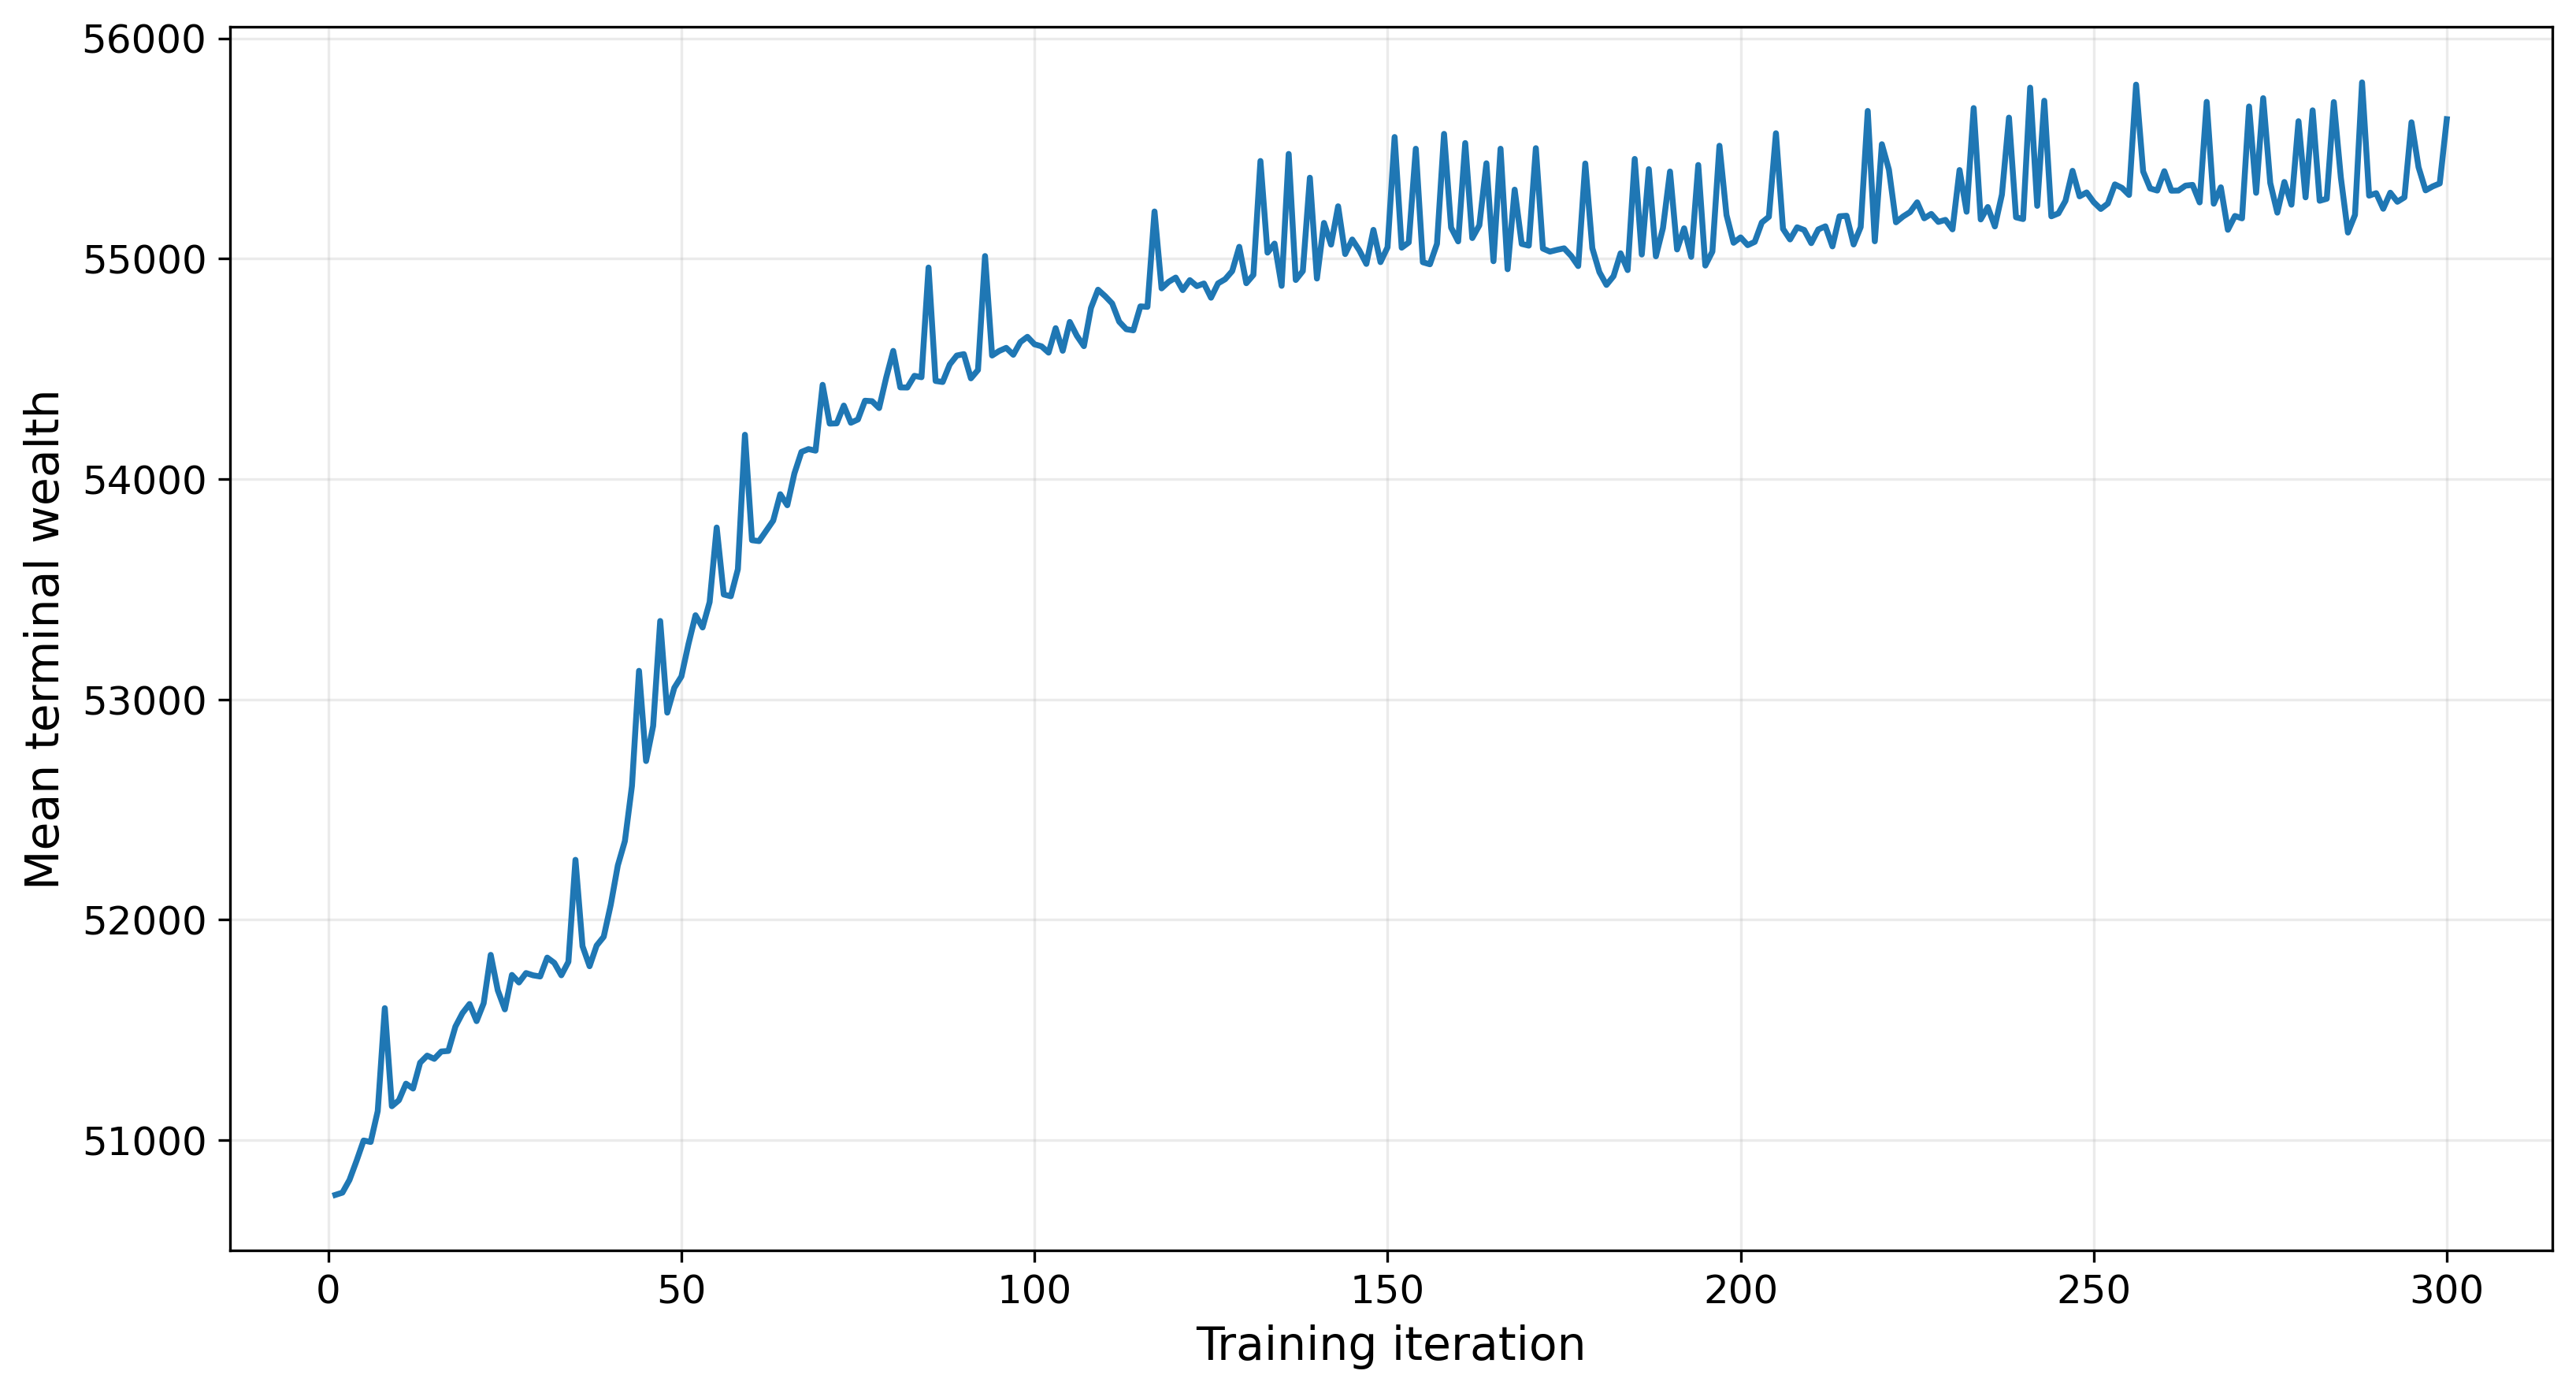

In [4]:
# Training plot 1: terminal wealth for each training iteration, no discounting.
if not history or "iter" not in history:
    print("No training history found in the checkpoint. Training plots cannot be produced from this .pt file.")
else:
    iters = np.asarray(history["iter"], dtype=float)
    if "train_terminal_wealth_mean" not in history:
        print("history['train_terminal_wealth_mean'] is missing.")
    else:
        y = np.asarray(history["train_terminal_wealth_mean"], dtype=float)
        plt.figure(figsize=(11, 6), dpi=300)
        plt.plot(iters, y, linewidth=1.8)
        #plt.title("Training: terminal wealth per iteration (no discounting)")
        plt.xlabel("Training iteration", fontsize=14)
        plt.ylabel("Mean terminal wealth", fontsize=14)
        plt.tick_params(axis='both', labelsize=12)
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "training_terminal_wealth.png", dpi=300, bbox_inches="tight")
        plt.show()

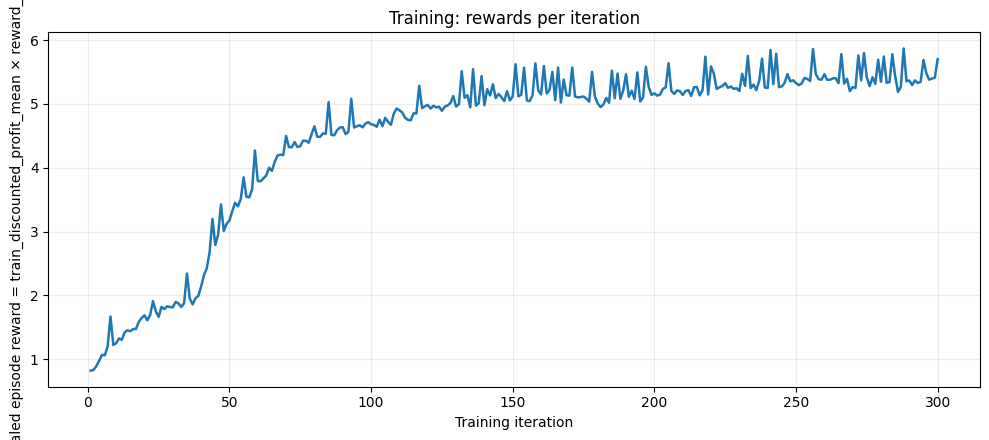

In [5]:
# Training plot 2: rewards for each training iteration.
if history and "iter" in history:
    iters = np.asarray(history["iter"], dtype=float)
    reward_key = None
    reward_label = None
    reward_values = None

    for key in ["train_reward_mean", "train_reward_sum_mean", "train_episode_reward_mean"]:
        if key in history:
            reward_key = key
            reward_values = np.asarray(history[key], dtype=float)
            reward_label = key
            break

    if reward_values is None and "train_discounted_profit_mean" in history:
        reward_key = "train_discounted_profit_mean"
        reward_values = np.asarray(history[reward_key], dtype=float) * float(market_config.reward_scale)
        reward_label = "scaled episode reward = train_discounted_profit_mean × reward_scale"

    if reward_values is None:
        print("No reward-like key was found in checkpoint history.")
    else:
        plt.figure(figsize=(10, 4.5))
        plt.plot(iters, reward_values, linewidth=1.8)
        plt.title("Training: rewards per iteration")
        plt.xlabel("Training iteration")
        plt.ylabel(reward_label)
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "training_rewards.png", dpi=160, bbox_inches="tight")
        plt.show()

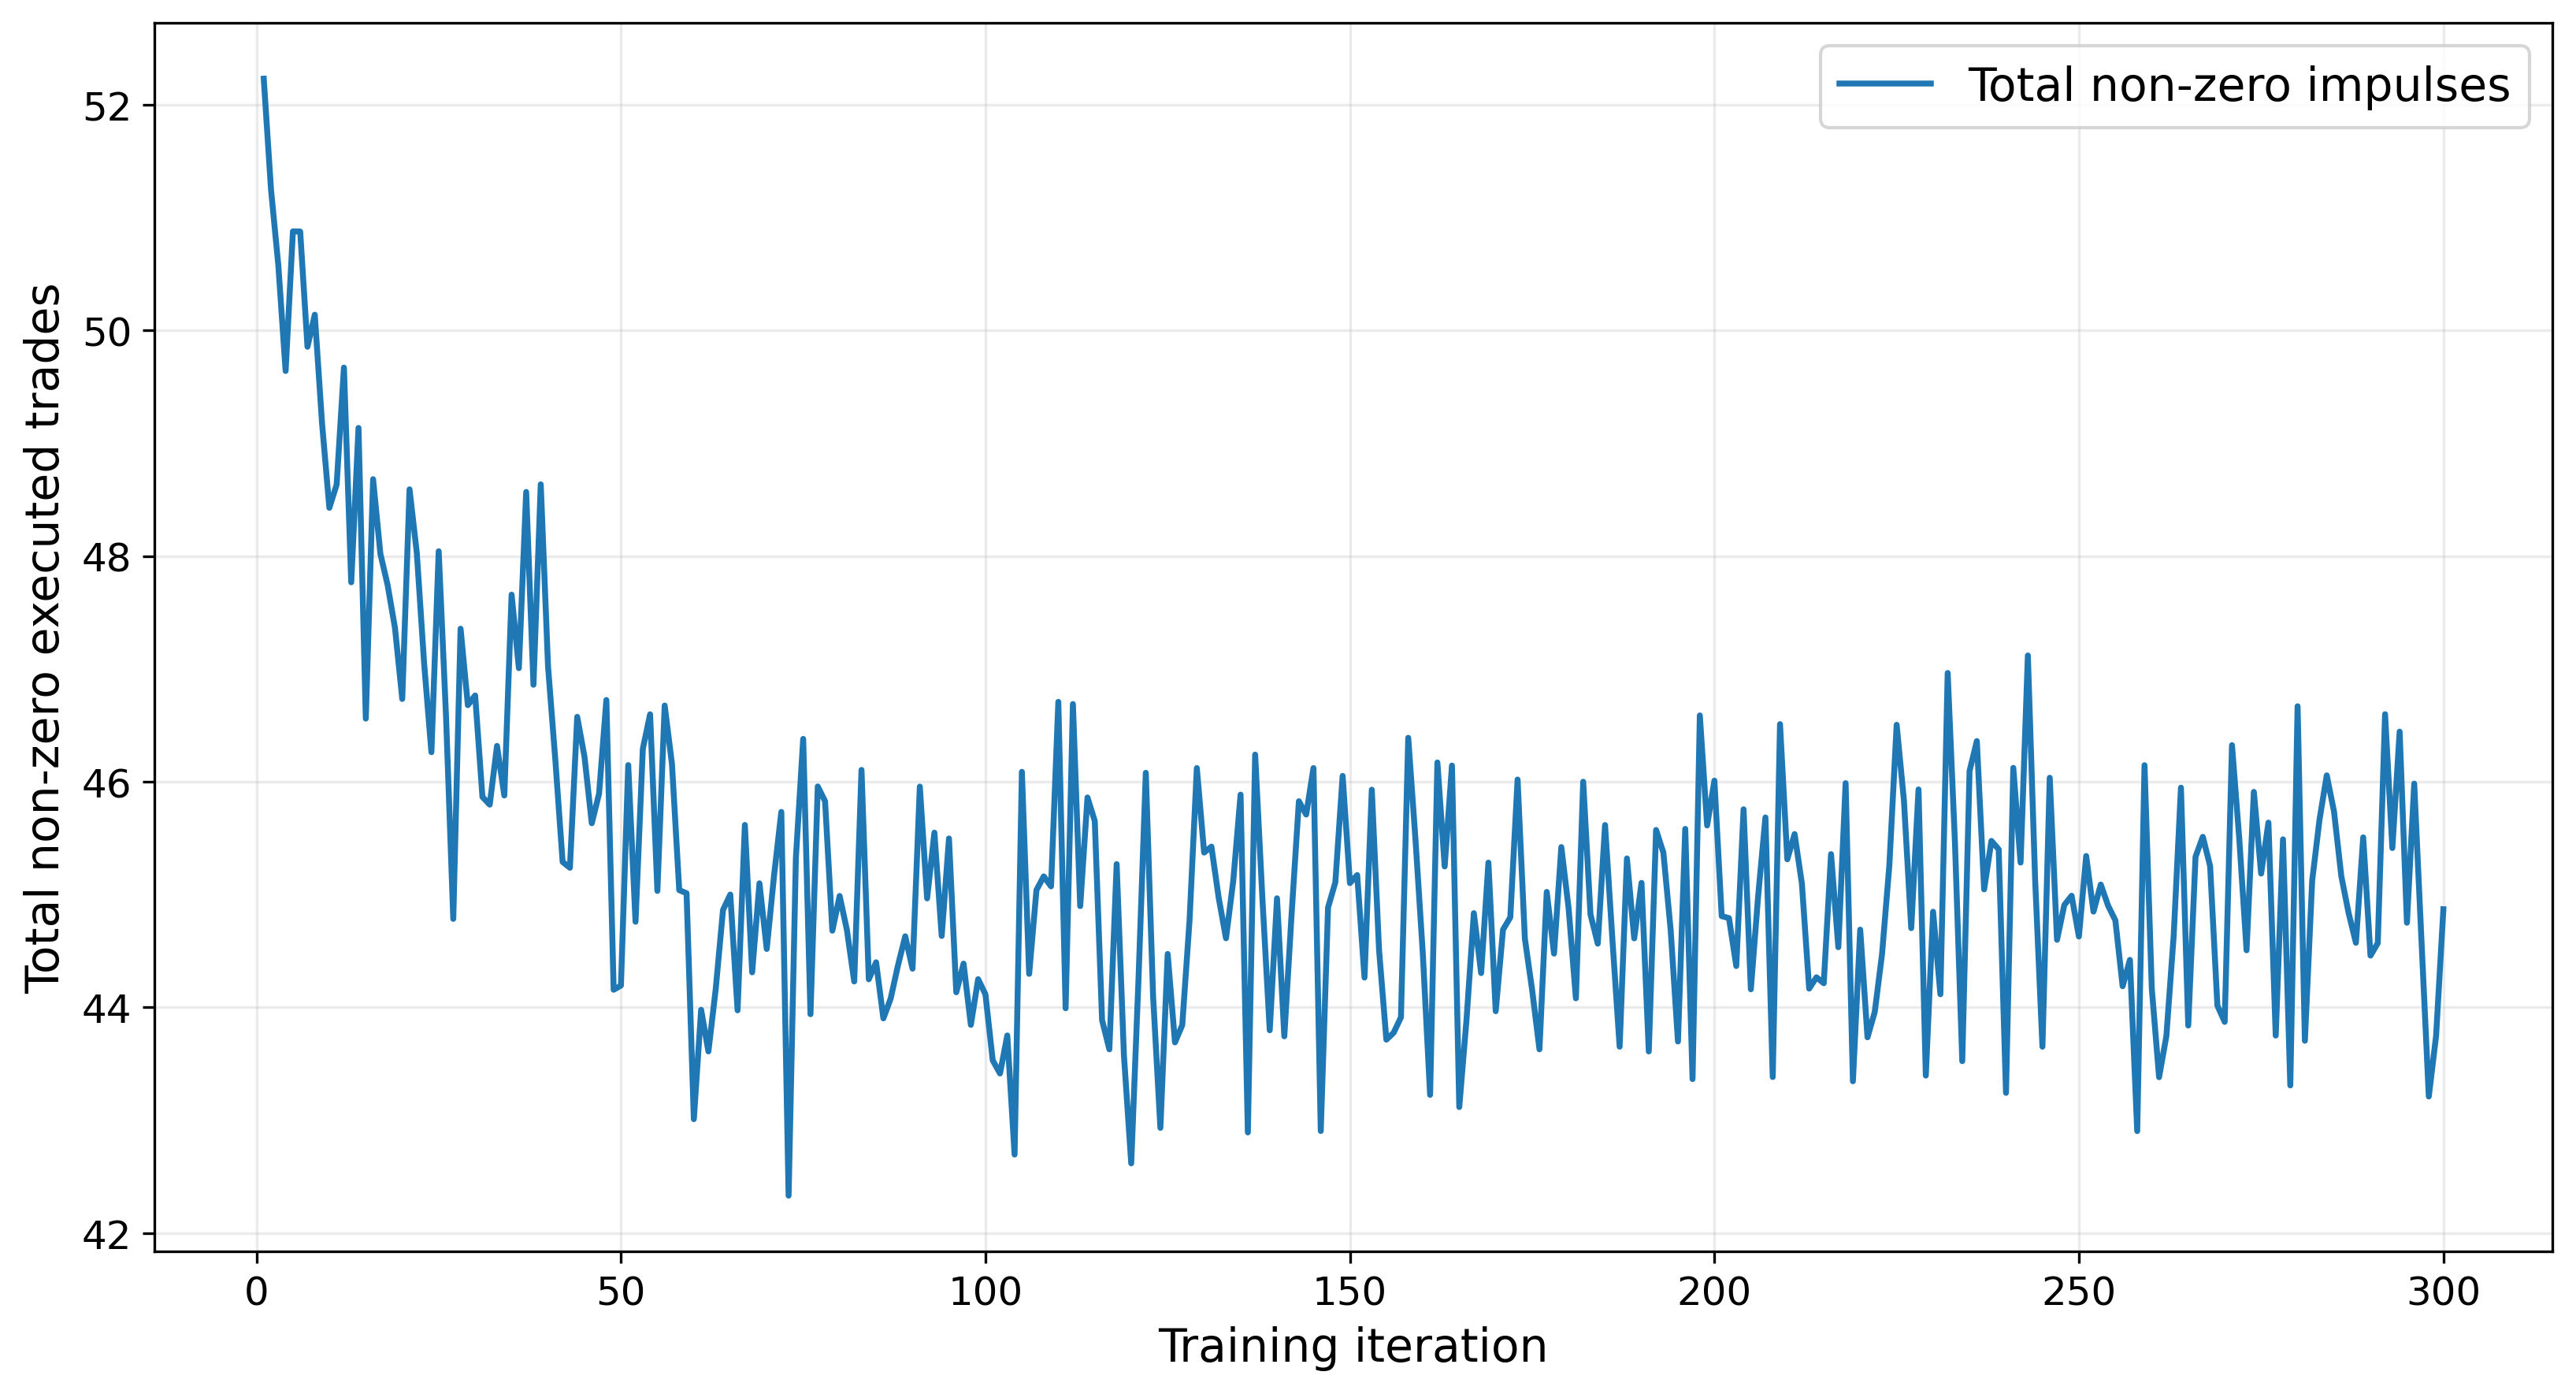

In [6]:
# Training plot 3: total absolute number of trades per training iteration.
# The checkpoint stores mean non-zero impulse count per rollout path. Multiply by rollout_envs
# to get the total non-zero impulse count in each training rollout iteration.
if history and "iter" in history:
    iters = np.asarray(history["iter"], dtype=float)
    if "train_trade_count_mean" not in history:
        print("history['train_trade_count_mean'] is missing.")
    else:
        total_trade_count = np.asarray(history["train_trade_count_mean"], dtype=float) * float(train_config.rollout_envs)
        plt.figure(figsize=(11, 6), dpi=300)
        plt.plot(iters, total_trade_count/1024, linewidth=1.8, label="Total non-zero impulses")
        #plt.title("Training: total absolute number of trades per iteration")
        plt.xlabel("Training iteration", fontsize=14)
        plt.ylabel("Total non-zero executed trades", fontsize=14)
        plt.tick_params(axis='both', labelsize=12)
        plt.grid(True, alpha=0.25)
        plt.legend(loc="best", fontsize=14)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "training_total_trades.png", dpi=300, bbox_inches="tight")
        plt.show()

## Shared-path stochastic policy evaluator

The helper below evaluates PPO-SIL on a supplied tensor of stock-price paths. It is used for both the 5000-path average evaluation and the one averaged path. It uses `deterministic=False` by default.

In [7]:
@torch.no_grad()
def run_policy_on_price_paths(agent, env, price_paths_cpu, *, batch_size=256, deterministic=False, collect_details=False):
    price_paths_cpu = torch.as_tensor(price_paths_cpu, dtype=torch.float32, device="cpu")
    n_paths, steps_plus_one, d = price_paths_cpu.shape
    steps = steps_plus_one - 1
    if steps != int(env.cfg.n_steps):
        raise ValueError(f"price_paths have {steps} steps, but env has n_steps={env.cfg.n_steps}.")
    if d != env.d:
        raise ValueError(f"price_paths have d={d}, but env has d={env.d}.")

    wealth = np.empty((n_paths, steps_plus_one), dtype=np.float64)
    discounted_wealth = np.empty((n_paths, steps_plus_one), dtype=np.float64)
    trades = np.empty((n_paths, steps, d), dtype=np.float64)
    costs = np.empty((n_paths, steps), dtype=np.float64)
    interventions = np.empty((n_paths, steps), dtype=np.int64)
    decision_prob = np.empty((n_paths, steps), dtype=np.float64)

    if collect_details:
        holdings = np.empty((n_paths, steps_plus_one, d), dtype=np.float64)
        cash = np.empty((n_paths, steps_plus_one), dtype=np.float64)
        prices = np.empty((n_paths, steps_plus_one, d), dtype=np.float64)
    else:
        holdings = cash = prices = None

    agent.eval()
    for start in range(0, n_paths, int(batch_size)):
        end = min(start + int(batch_size), n_paths)
        b = end - start
        pp = price_paths_cpu[start:end].to(device=env.device, dtype=env.dtype)
        state = env.reset(b, price_paths=pp)

        wealth[start:end, 0] = env.wealth(state).detach().cpu().numpy()
        discounted_wealth[start:end, 0] = env.discounted_wealth(state).detach().cpu().numpy()
        if collect_details:
            prices[start:end, 0, :] = state["s"].detach().cpu().numpy()
            holdings[start:end, 0, :] = state["h"].detach().cpu().numpy()
            cash[start:end, 0] = state["cash"].detach().cpu().numpy()

        for t in range(steps):
            obs = env.observe(state)
            act = agent.act(obs, deterministic=deterministic)
            next_state, reward, done, info = env.step(state, act["intervene"], act["trade_intent"])

            trades[start:end, t, :] = info["safe_trade"].detach().cpu().numpy()
            costs[start:end, t] = info["cost"].detach().cpu().numpy()
            interventions[start:end, t] = act["intervene"].detach().cpu().numpy()
            decision_prob[start:end, t] = act["prob_d"].detach().cpu().numpy()

            state = next_state
            wealth[start:end, t + 1] = env.wealth(state).detach().cpu().numpy()
            discounted_wealth[start:end, t + 1] = env.discounted_wealth(state).detach().cpu().numpy()
            if collect_details:
                prices[start:end, t + 1, :] = state["s"].detach().cpu().numpy()
                holdings[start:end, t + 1, :] = state["h"].detach().cpu().numpy()
                cash[start:end, t + 1] = state["cash"].detach().cpu().numpy()

        _clear_device_cache(env.device)

    out = {
        "wealth": wealth,
        "discounted_wealth": discounted_wealth,
        "trades": trades,
        "costs": costs,
        "intervene": interventions,
        "decision_prob": decision_prob,
    }
    if collect_details:
        out.update({"prices": prices, "holdings": holdings, "cash": cash})
    return out


def buy_and_hold_wealth(price_paths_cpu, env):
    price_np = torch.as_tensor(price_paths_cpu, dtype=torch.float64, device="cpu").numpy()
    h0 = np.asarray(env.cfg.h0, dtype=np.float64)
    cash0 = float(env.cfg.cash0)
    return cash0 + np.einsum("ntd,d->nt", price_np, h0)


def safe_divide(numer, denom, eps=1e-12):
    numer = np.asarray(numer, dtype=float)
    denom = np.asarray(denom, dtype=float)
    out = np.zeros(np.broadcast_shapes(numer.shape, denom.shape), dtype=float)
    return np.divide(numer, denom, out=out, where=np.abs(denom) > eps)

## Average evaluation plots, post-training

The cell below samples `N_MC = 5000` stock-price paths once, evaluates PPO-SIL stochastically on those paths, and computes buy-and-hold on the exact same paths. Wealth is not discounted in the plots.

In [8]:
# Generate the shared 5000-path evaluation set and evaluate both strategies.
set_seed(EVAL_SEED)
eval_price_paths_cpu = eval_env.sample_price_paths(int(N_MC_AVG)).detach().cpu()

# Stochastic policy evaluation: deterministic=False.
set_seed(EVAL_SEED)
ppo_avg_eval = run_policy_on_price_paths(
    agent,
    eval_env,
    eval_price_paths_cpu,
    batch_size=int(EVAL_BATCH_SIZE),
    deterministic=False,
    collect_details=False,
)

bh_avg_wealth = buy_and_hold_wealth(eval_price_paths_cpu, eval_env)
time_grid = np.linspace(0.0, float(eval_env.cfg.T), int(eval_env.cfg.n_steps) + 1)

print(f"Evaluated PPO-SIL and buy-and-hold on the same {N_MC_AVG} paths with N_t={N_T_EVAL}.")

Evaluated PPO-SIL and buy-and-hold on the same 5000 paths with N_t=252.


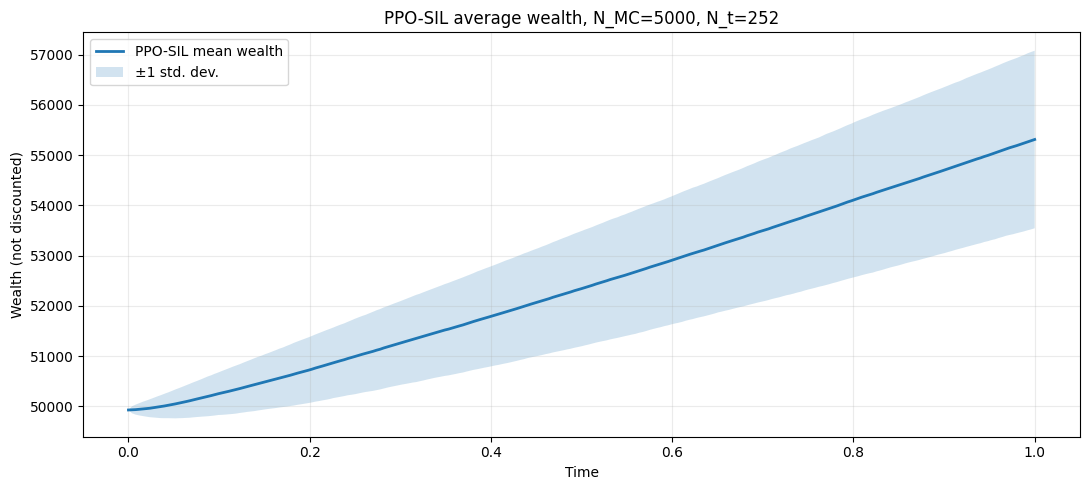

In [9]:
# Average evaluation plot 1: PPO-SIL average wealth with standard deviation fill.
ppo_wealth = ppo_avg_eval["wealth"]
ppo_mean = ppo_wealth.mean(axis=0)
ppo_std = ppo_wealth.std(axis=0, ddof=0)

plt.figure(figsize=(11, 5))
plt.plot(time_grid, ppo_mean, linewidth=2.0, label="PPO-SIL mean wealth")
plt.fill_between(time_grid, ppo_mean - ppo_std, ppo_mean + ppo_std, alpha=0.20, label="±1 std. dev.")
plt.title(f"PPO-SIL average wealth, N_MC={N_MC_AVG}, N_t={N_T_EVAL}")
plt.xlabel("Time")
plt.ylabel("Wealth (not discounted)")
plt.grid(True, alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "avg_ppo_sil_wealth_std_fill.png", dpi=160, bbox_inches="tight")
plt.show()

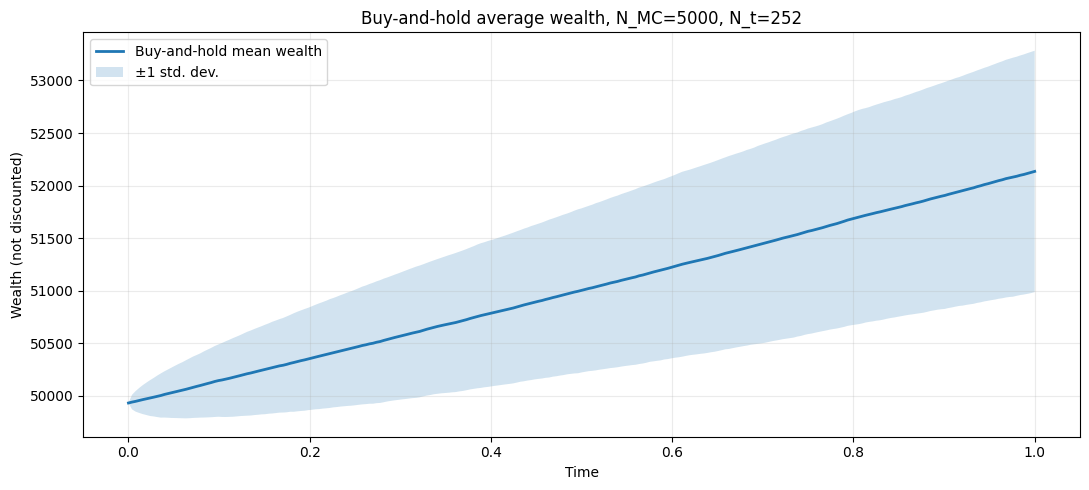

In [10]:
# Average evaluation plot 2: buy-and-hold average wealth with standard deviation fill.
bh_mean = bh_avg_wealth.mean(axis=0)
bh_std = bh_avg_wealth.std(axis=0, ddof=0)

plt.figure(figsize=(11, 5))
plt.plot(time_grid, bh_mean, linewidth=2.0, label="Buy-and-hold mean wealth")
plt.fill_between(time_grid, bh_mean - bh_std, bh_mean + bh_std, alpha=0.20, label="±1 std. dev.")
plt.title(f"Buy-and-hold average wealth, N_MC={N_MC_AVG}, N_t={N_T_EVAL}")
plt.xlabel("Time")
plt.ylabel("Wealth (not discounted)")
plt.grid(True, alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "avg_buy_and_hold_wealth_std_fill.png", dpi=160, bbox_inches="tight")
plt.show()

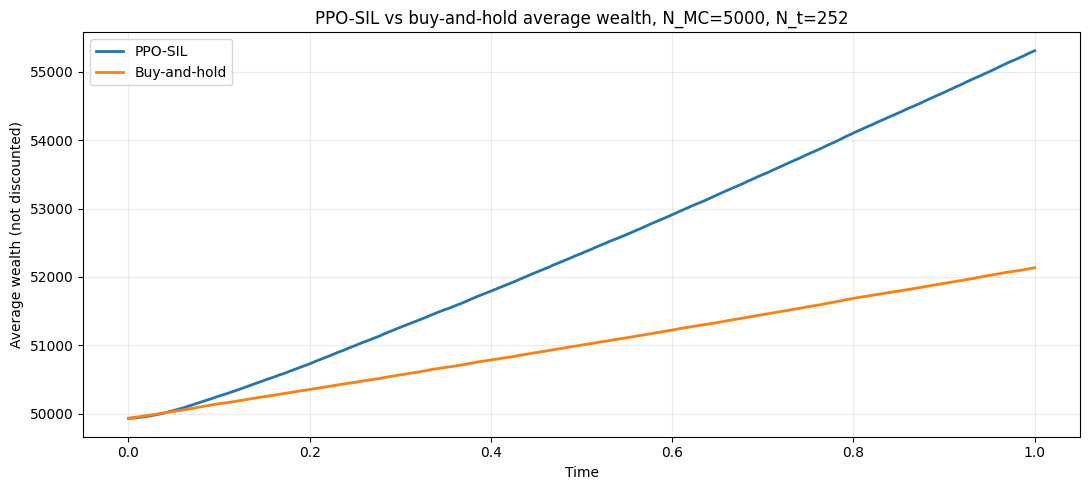

In [11]:
# Average evaluation plot 3: PPO-SIL vs buy-and-hold average wealth, no standard deviation fills.
plt.figure(figsize=(11, 5))
plt.plot(time_grid, ppo_mean, linewidth=2.0, label="PPO-SIL")
plt.plot(time_grid, bh_mean, linewidth=2.0, label="Buy-and-hold")
plt.title(f"PPO-SIL vs buy-and-hold average wealth, N_MC={N_MC_AVG}, N_t={N_T_EVAL}")
plt.xlabel("Time")
plt.ylabel("Average wealth (not discounted)")
plt.grid(True, alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "avg_ppo_sil_vs_buy_and_hold.png", dpi=160, bbox_inches="tight")
plt.show()

## One-path evaluation plots, post-training

This section samples `N_MC = 20` stock-price paths, averages them asset-by-asset into one path, and evaluates both PPO-SIL and buy-and-hold on that averaged path. PPO-SIL remains stochastic (`deterministic=False`).

In [12]:
# Build the averaged one-path diagnostic path and evaluate both strategies.
set_seed(EVAL_SEED + 1)
one_path_samples_cpu = eval_env.sample_price_paths(int(N_MC_ONE_PATH)).detach().cpu()
avg_stock_path_cpu = one_path_samples_cpu.mean(dim=0, keepdim=True)

set_seed(EVAL_SEED + 1)
ppo_one_eval = run_policy_on_price_paths(
    agent,
    eval_env,
    avg_stock_path_cpu,
    batch_size=1,
    deterministic=False,
    collect_details=True,
)

bh_one_wealth = buy_and_hold_wealth(avg_stock_path_cpu, eval_env)[0]
avg_stock_path_np = avg_stock_path_cpu[0].numpy()

print(f"Created one averaged stock path from {N_MC_ONE_PATH} simulations and evaluated PPO-SIL stochastically.")

Created one averaged stock path from 1 simulations and evaluated PPO-SIL stochastically.


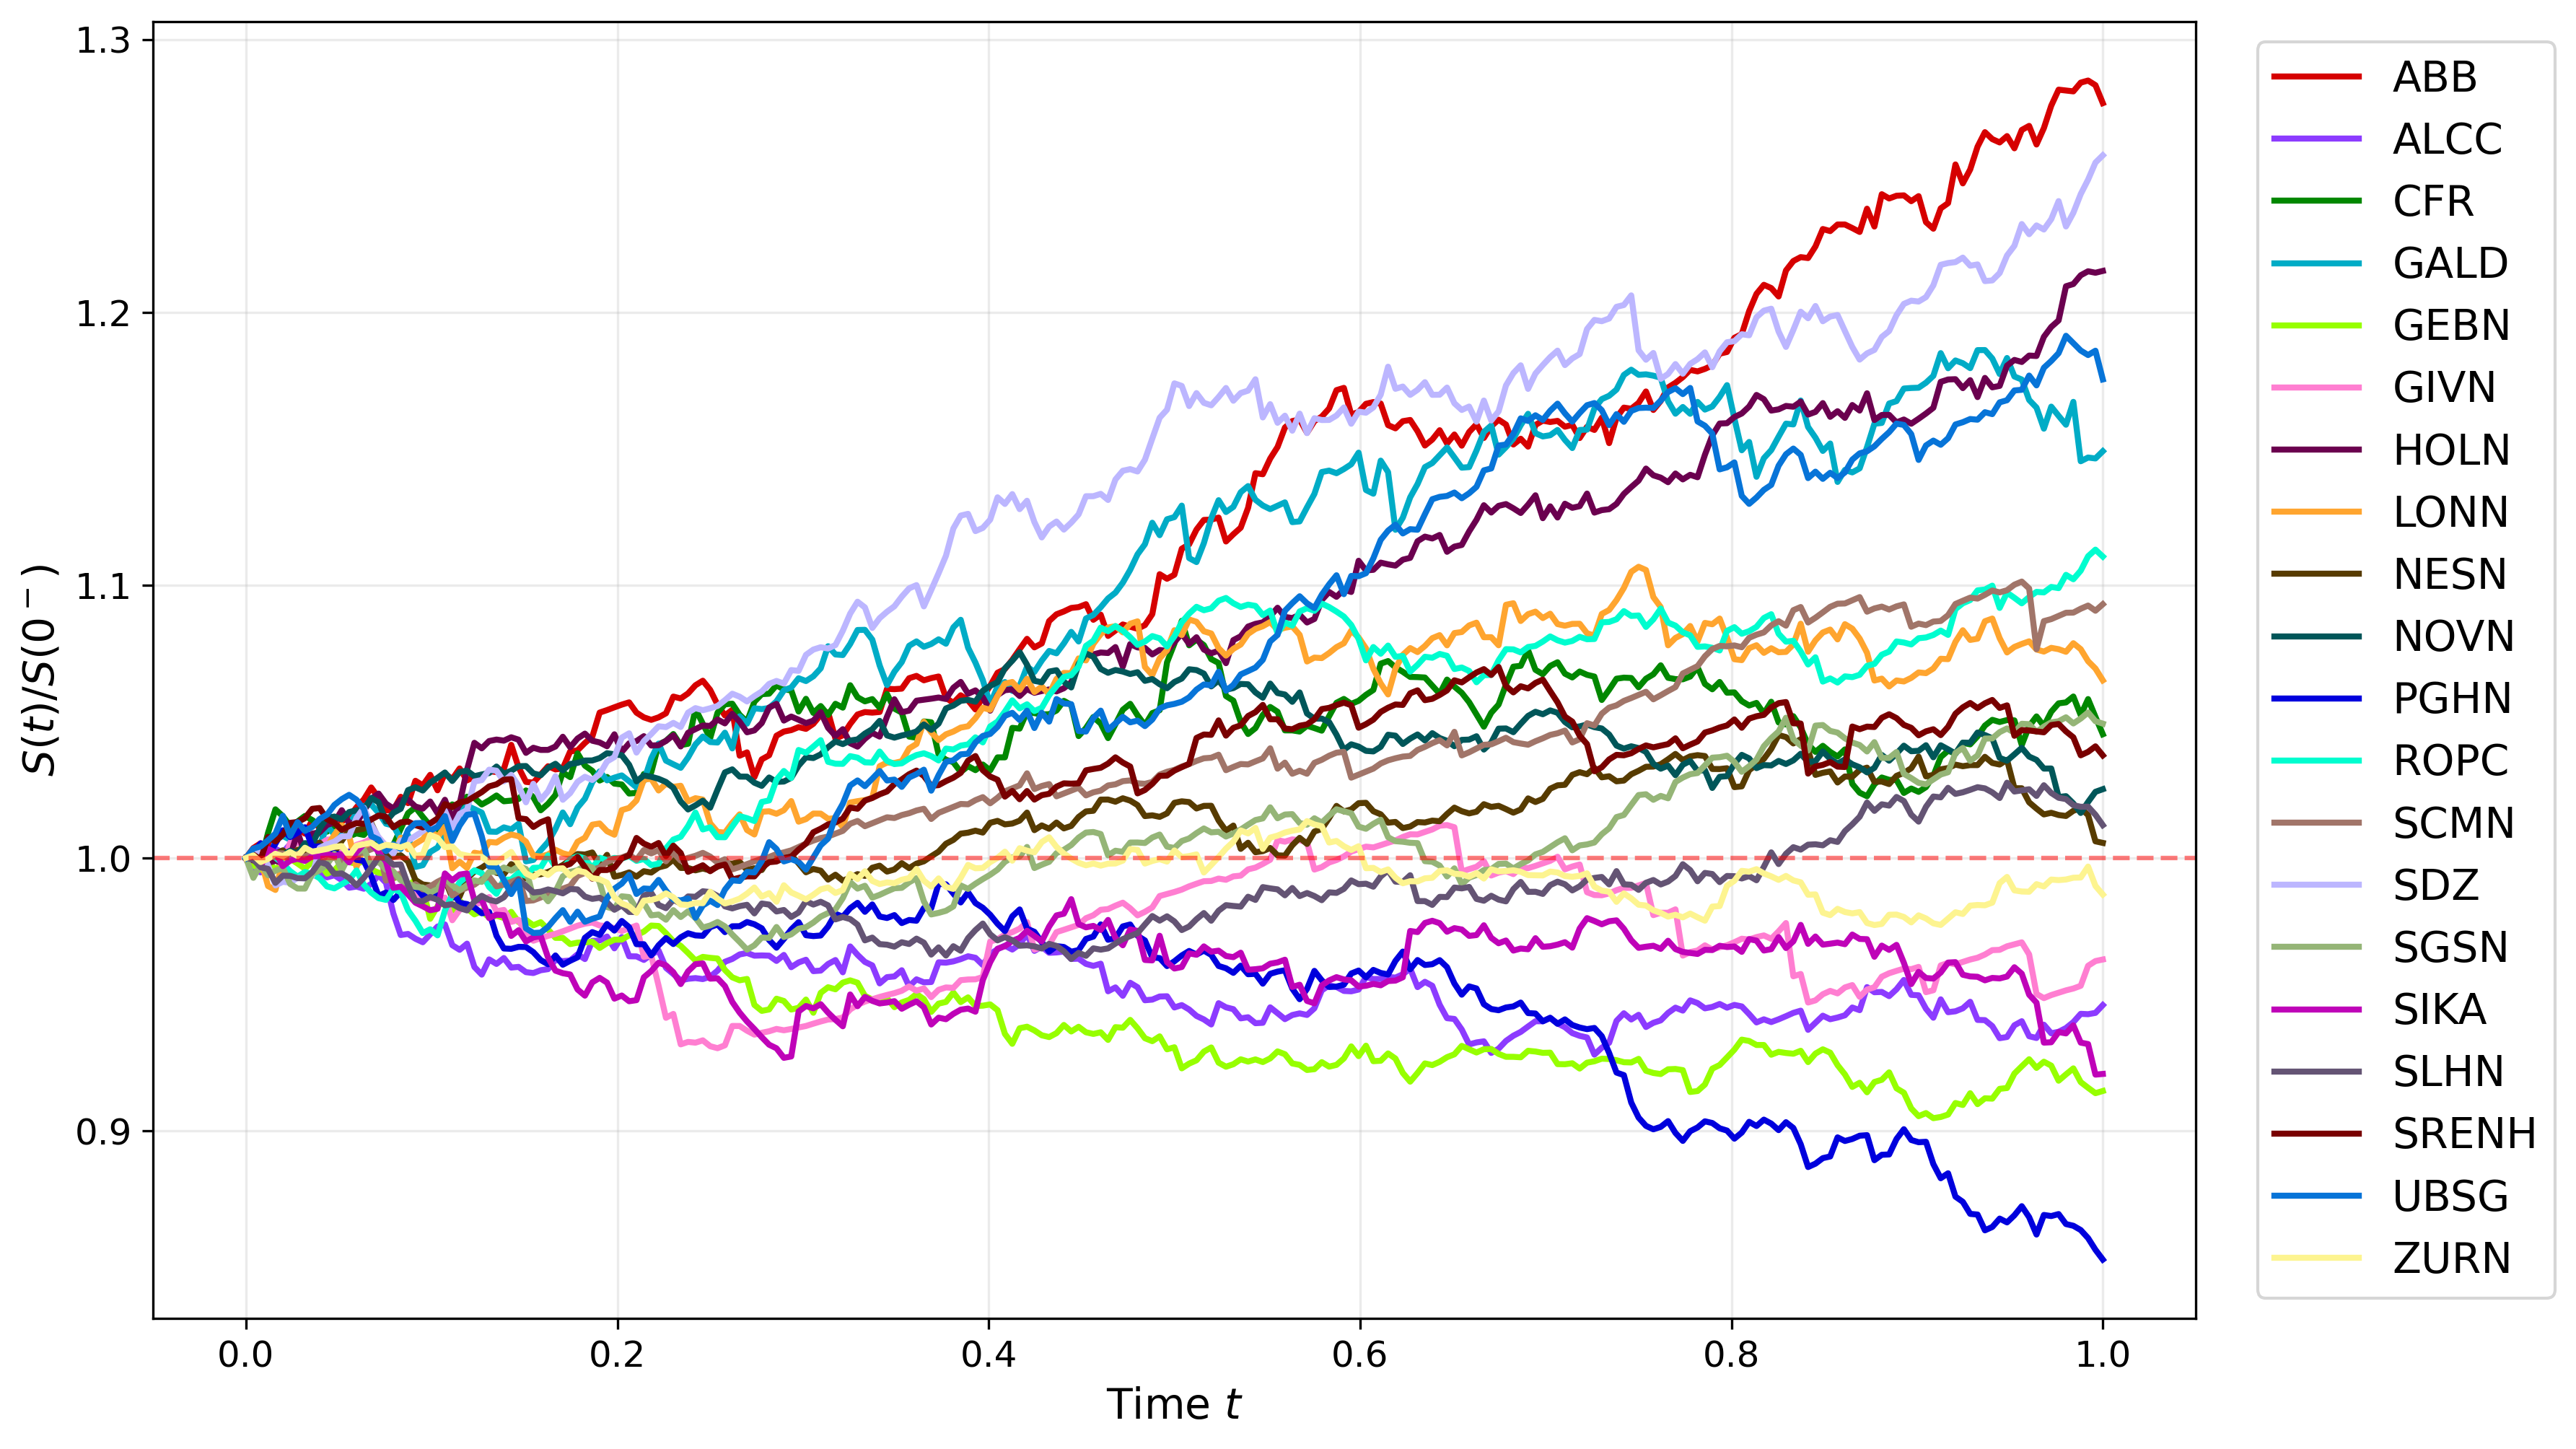

In [13]:
# One-path plot 1: normalized stock prices S(t) / S(0), all assets in one figure.
plt.figure(figsize=(12, 7), dpi=300)
for j, name in enumerate(asset_names):
    normalized = avg_stock_path_np[:, j] / max(float(avg_stock_path_np[0, j]), 1.0e-12)
    plt.plot(time_grid, normalized, linewidth=2.0, label=name, color=asset_colors[name])
#plt.title(f"Averaged stock path: S(t) / S(0), averaged over N_MC={N_MC_ONE_PATH}")
plt.tick_params(axis="both", labelsize=12)
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5)
plt.xlabel(r"Time $t$", fontsize=14)
plt.ylabel(r"$S(t)/S(0^-)$", fontsize=14)
plt.grid(True, alpha=0.25)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "one_path_normalized_stock_prices.png", dpi=300, bbox_inches="tight")
plt.show()

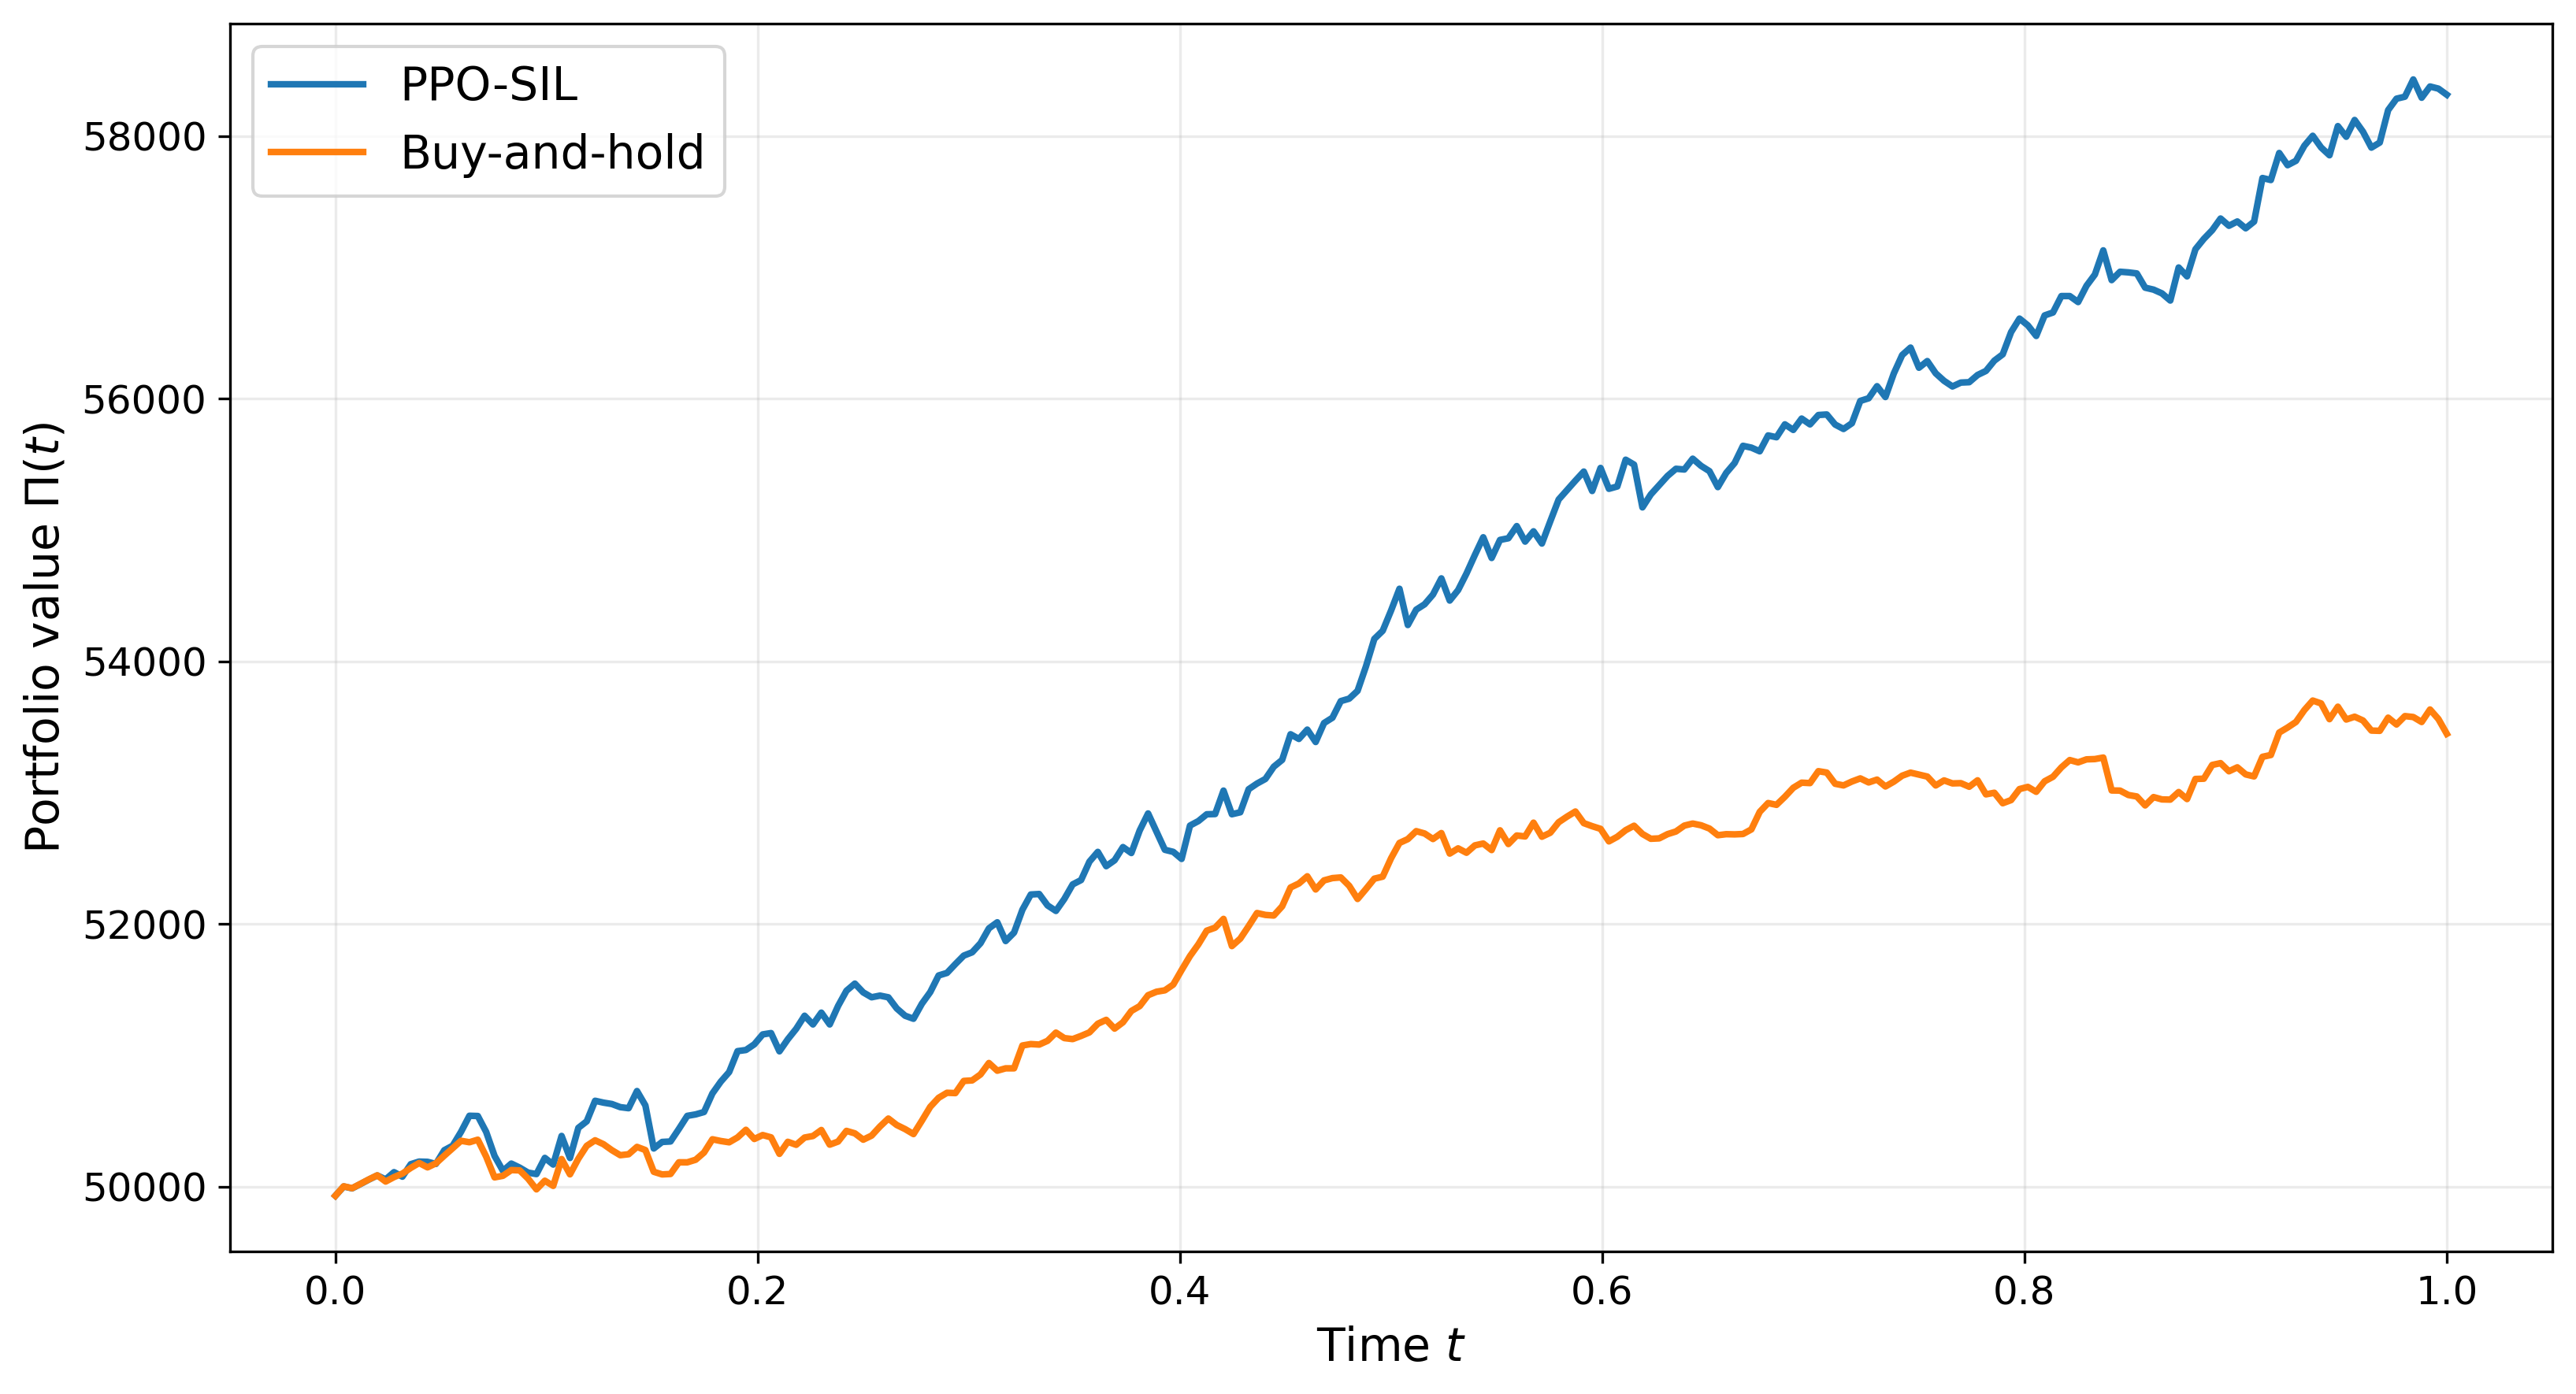

In [14]:
# One-path plot 2: PPO-SIL vs buy-and-hold wealth on the averaged path.
ppo_one_wealth = ppo_one_eval["wealth"][0]

plt.figure(figsize=(11, 6), dpi=300)
plt.plot(time_grid, ppo_one_wealth, linewidth=2.0, label="PPO-SIL")
plt.plot(time_grid, bh_one_wealth, linewidth=2.0, label="Buy-and-hold")
#plt.title("One averaged path: PPO-SIL vs buy-and-hold wealth")
plt.tick_params(axis="both", labelsize=12)
plt.xlabel(r'Time $t$', fontsize=14)
plt.ylabel(r'Portfolio value $\Pi(t)$', fontsize=14)
plt.grid(True, alpha=0.25)
plt.legend(loc="best", fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "one_path_ppo_sil_vs_buy_and_hold.png", dpi=300, bbox_inches="tight")
plt.show()

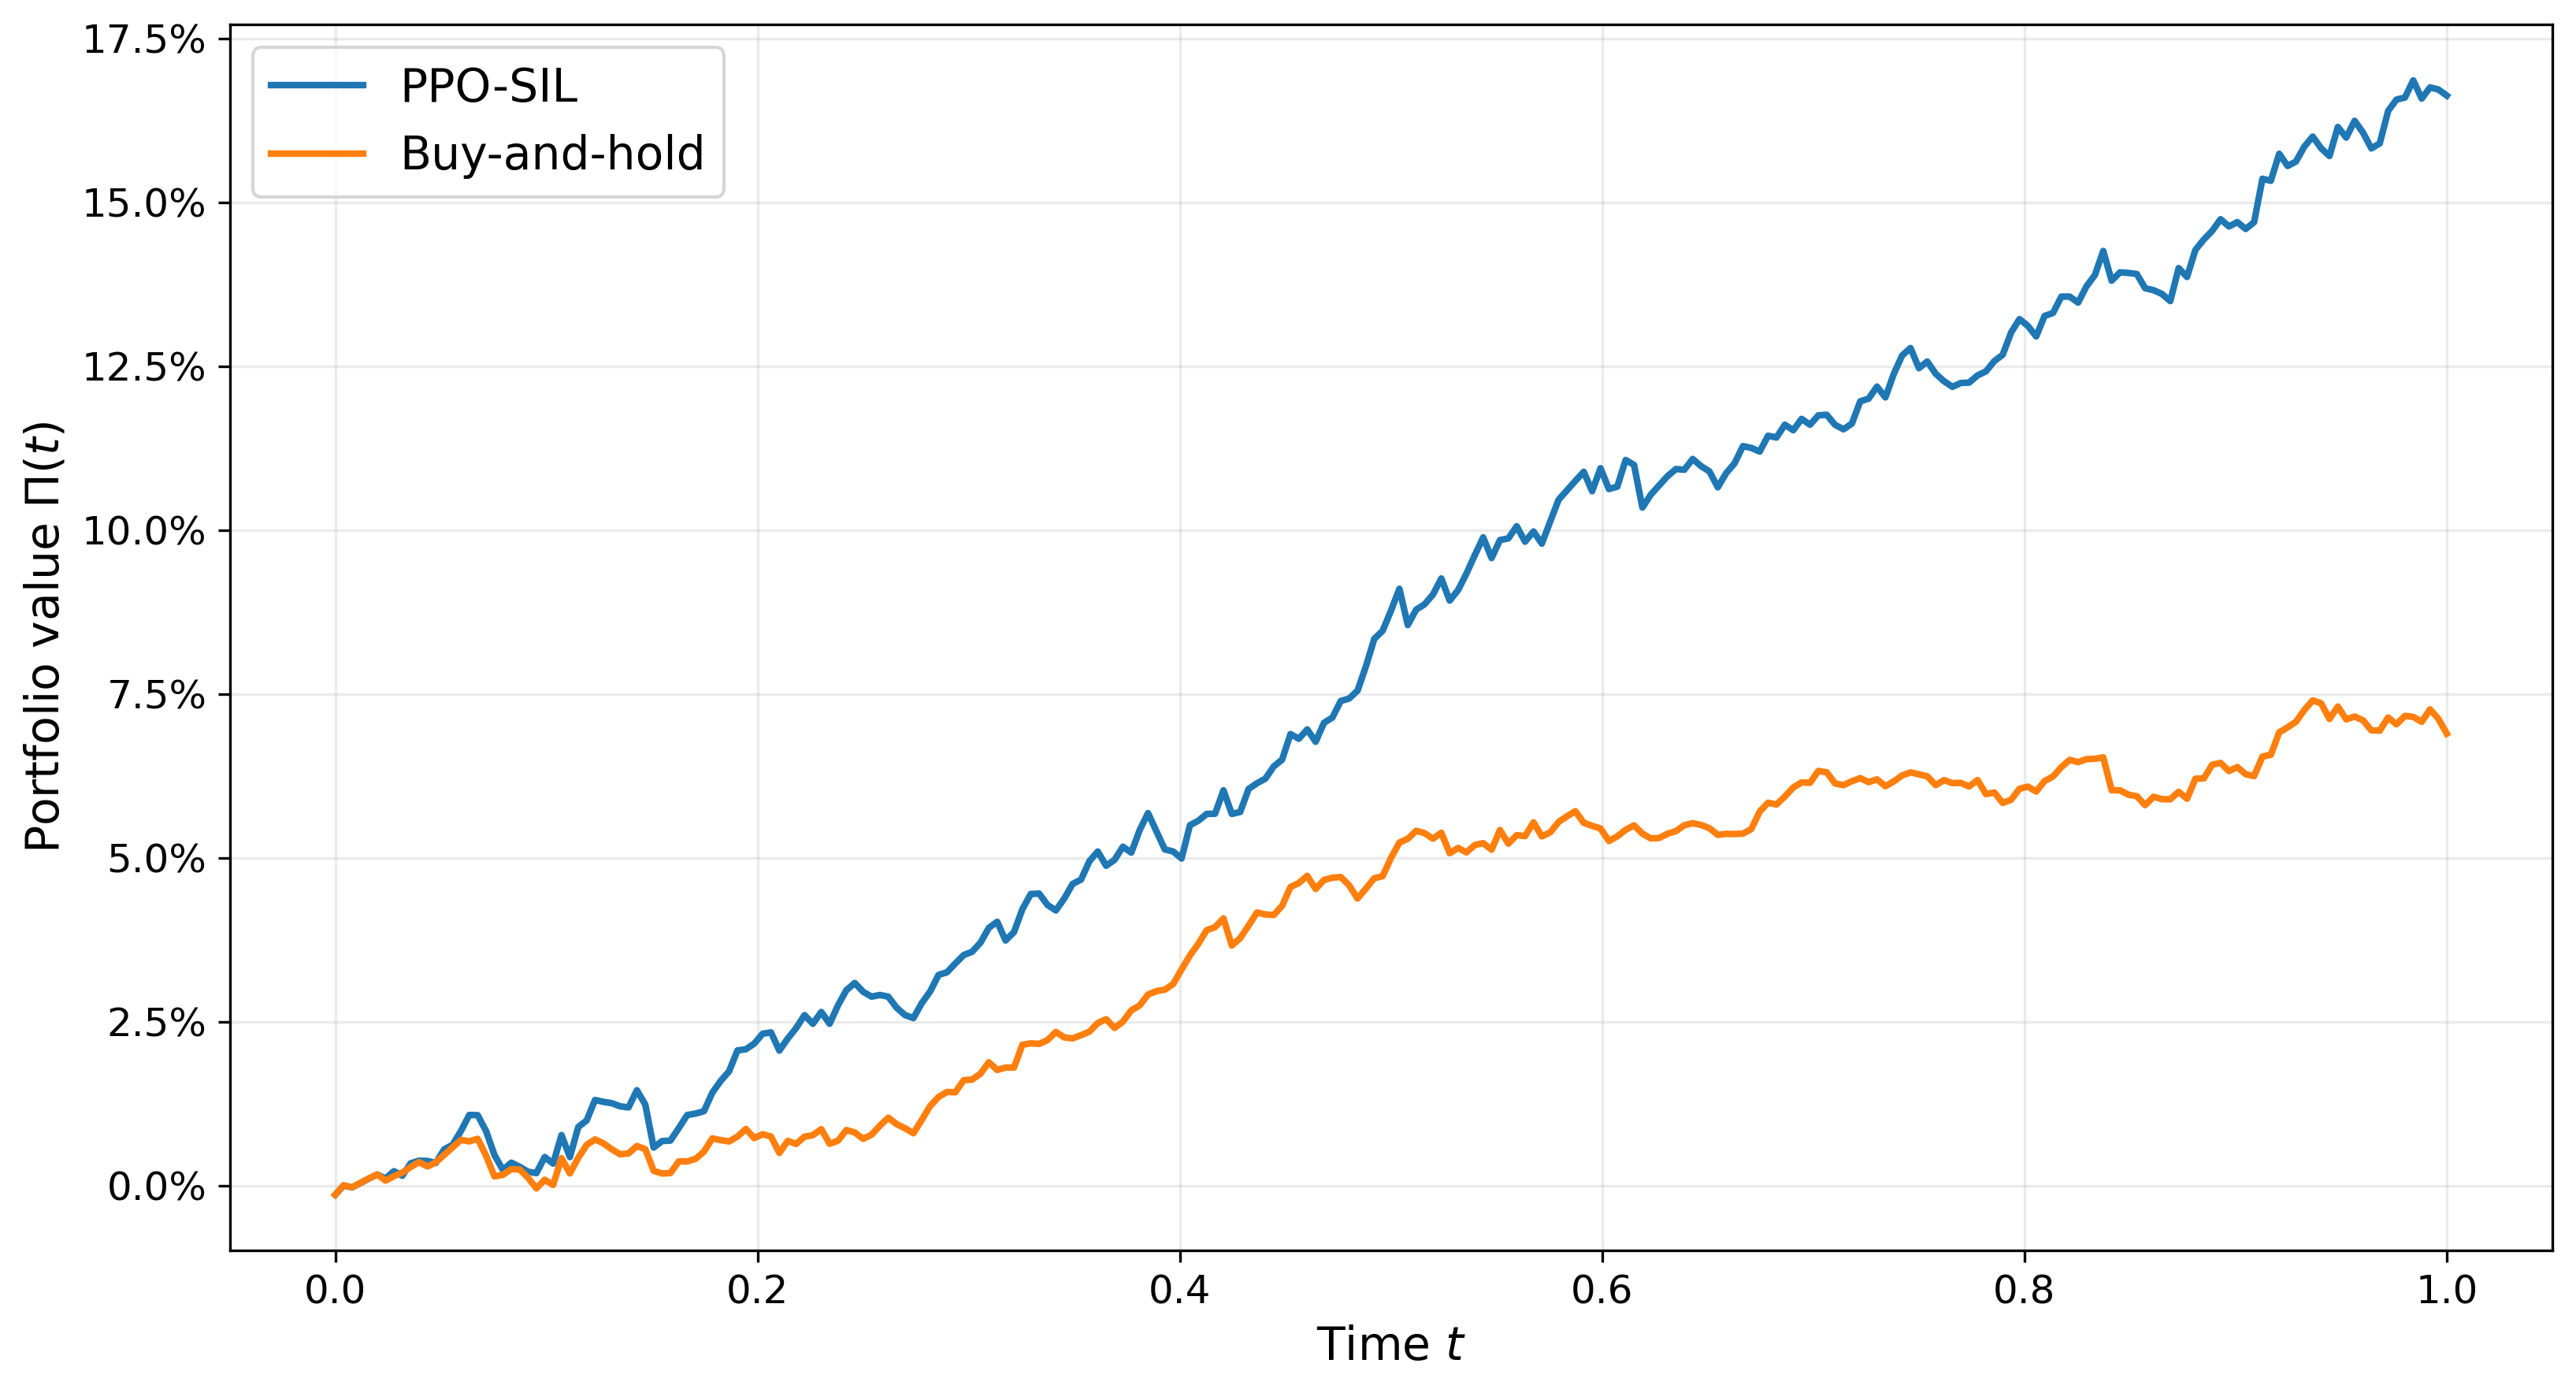

In [15]:
import matplotlib.ticker as mtick

ppo_one_wealth = ppo_one_eval["wealth"][0]

plt.figure(figsize=(11, 6), dpi=300)
plt.plot(time_grid, ppo_one_wealth/50000-1, linewidth=2.0, label="PPO-SIL")
plt.plot(time_grid, bh_one_wealth/50000-1, linewidth=2.0, label="Buy-and-hold")
#plt.title("One averaged path: PPO-SIL vs buy-and-hold wealth")

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.tick_params(axis="both", labelsize=12)
plt.xlabel(r'Time $t$', fontsize=14)
plt.ylabel(r'Portfolio value $\Pi(t)$', fontsize=14)
plt.grid(True, alpha=0.25)
plt.legend(loc="best", fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "one_path_ppo_sil_vs_buy_and_hold_cumul_returns.png", dpi=300, bbox_inches="tight")
plt.show()

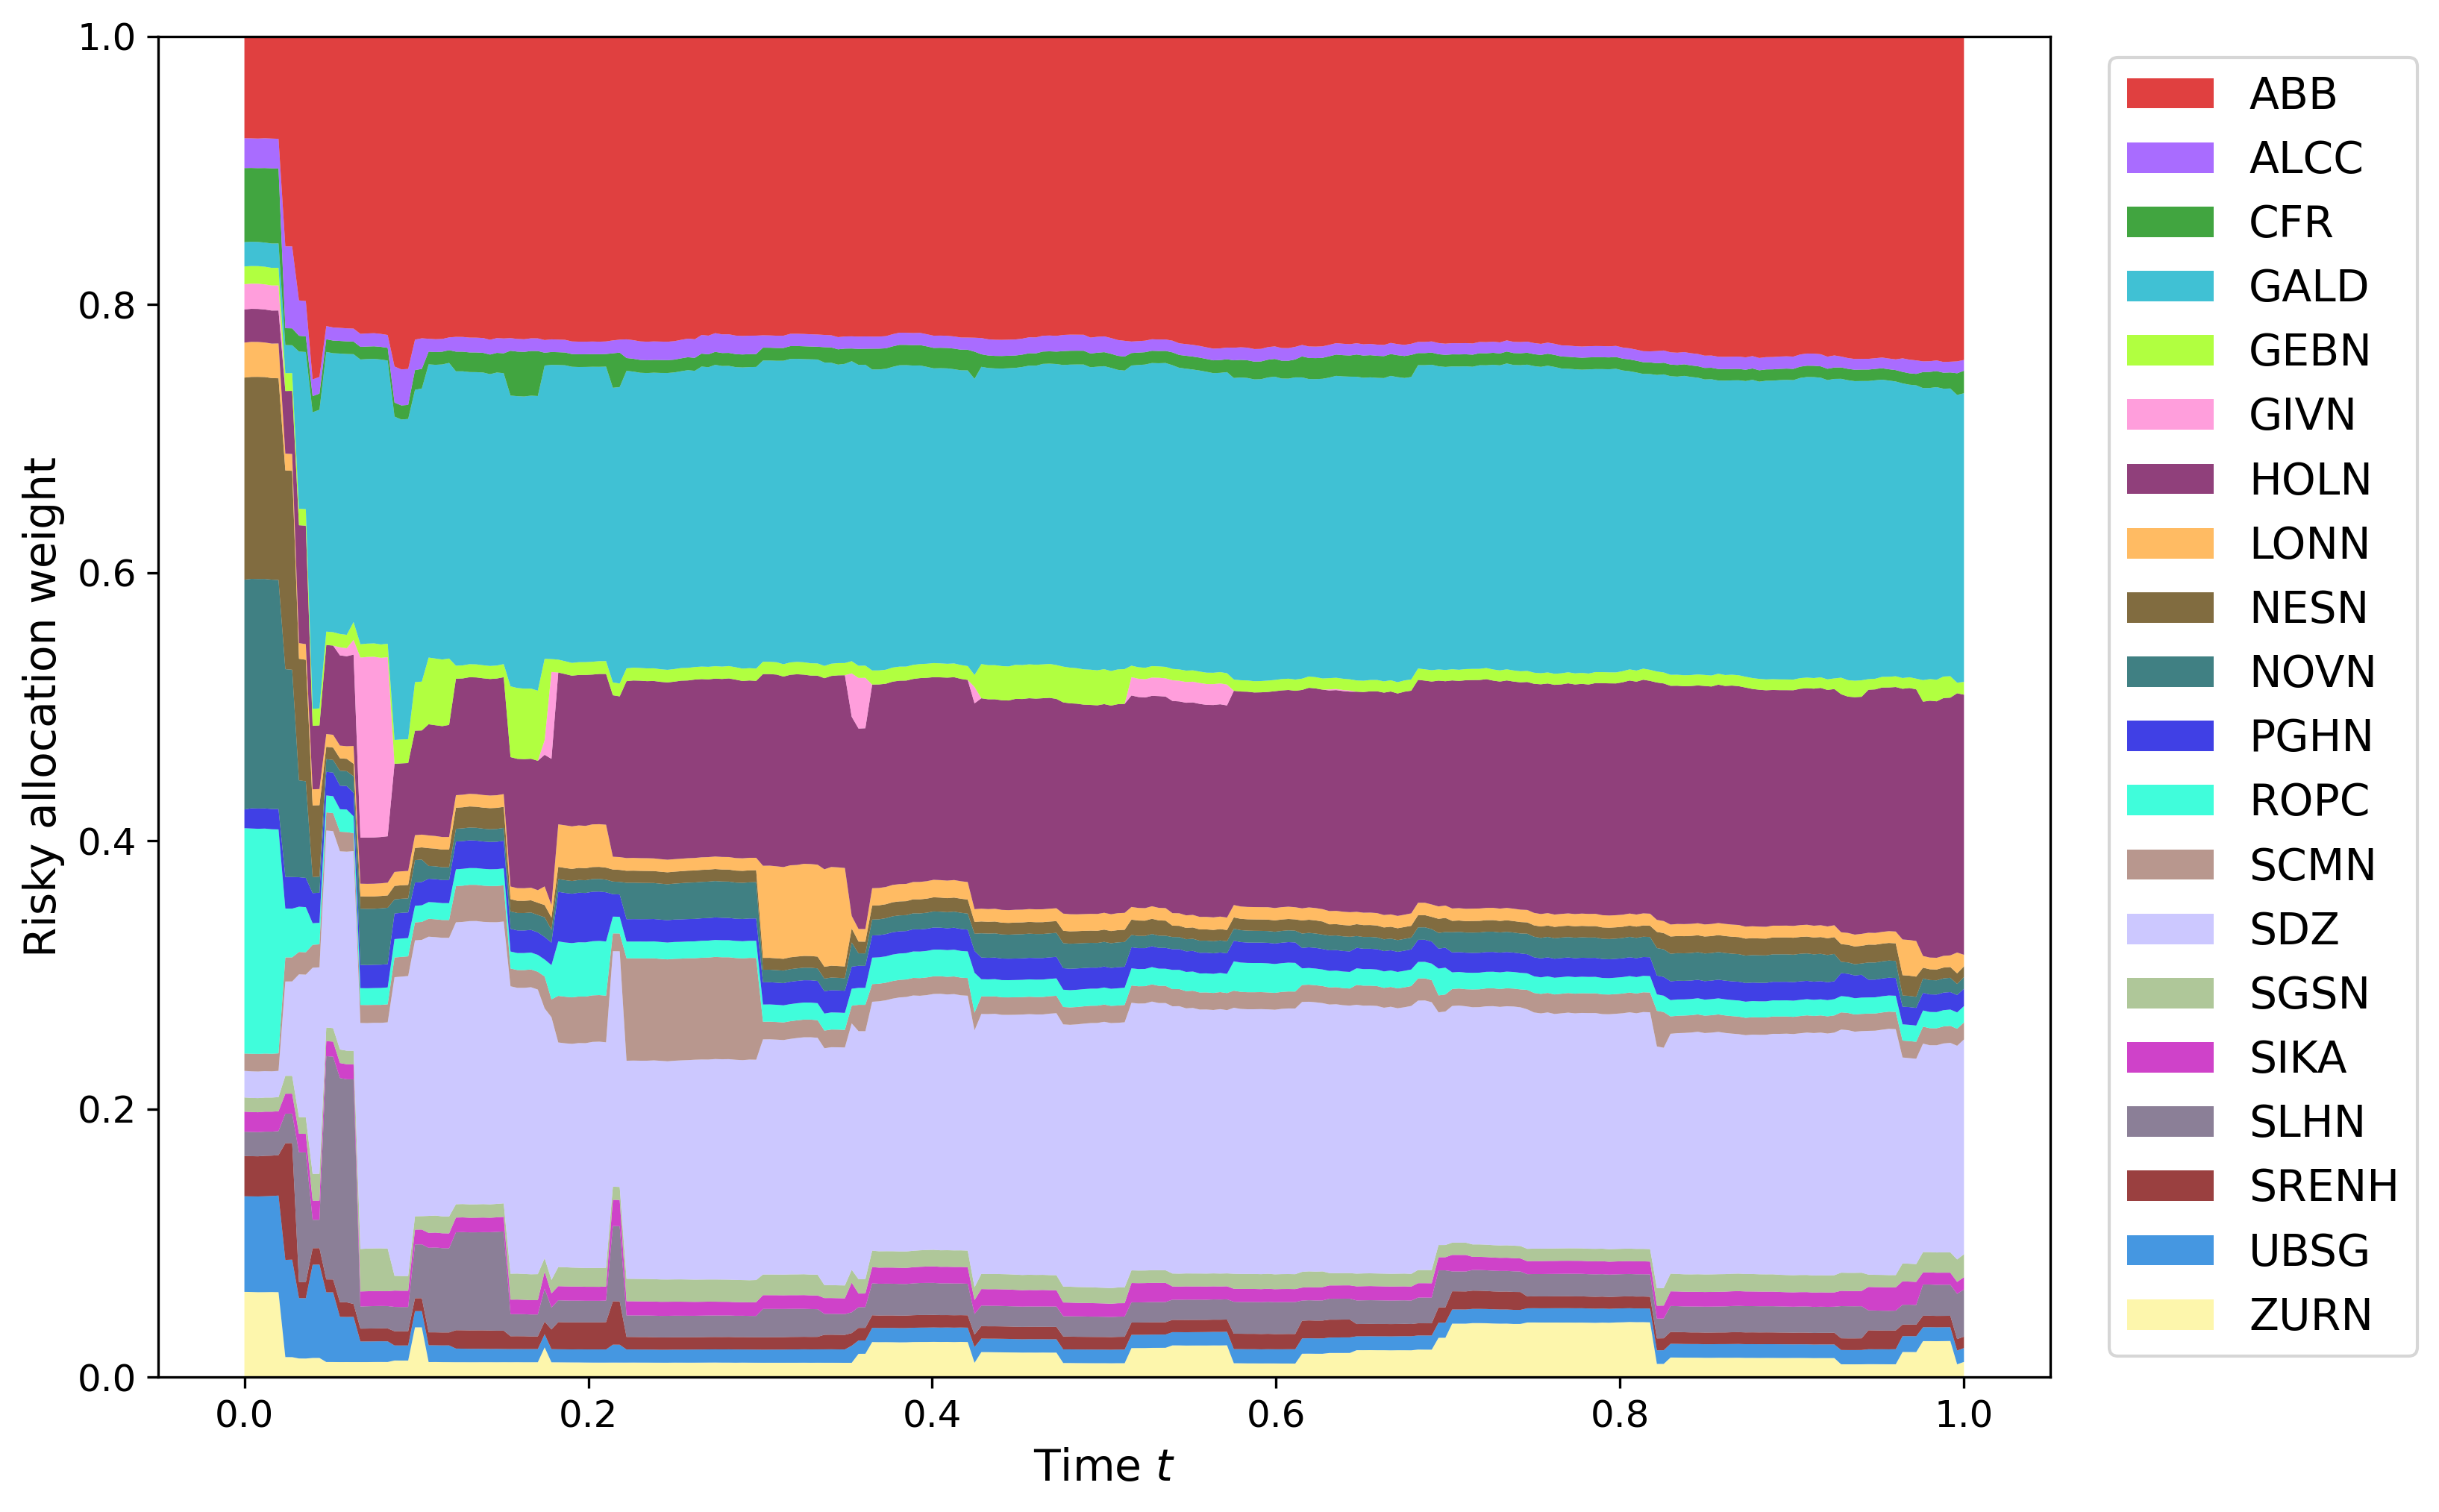

In [16]:
# One-path plot 3: PPO-SIL risky allocation through time.
one_holdings = ppo_one_eval["holdings"][0]
one_prices = ppo_one_eval["prices"][0]
one_asset_values = one_holdings * one_prices
one_risky_value = one_asset_values.sum(axis=1)
one_risky_weights = safe_divide(one_asset_values, one_risky_value[:, None])

# Reverse stack order: first plotted = bottom, last plotted = top.
asset_names_stack = list(asset_names)[::-1]
weights_stack = one_risky_weights[:, ::-1]

fig, ax = plt.subplots(figsize=(11, 7), dpi=300)
ax.stackplot(time_grid, weights_stack.T, labels=asset_names_stack, colors=[asset_colors[name] for name in asset_names_stack], alpha=0.75)

#ax.set_title("PPO-SIL risky allocation", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel(r'Time $t$', fontsize=14)
ax.set_ylabel("Risky allocation weight", fontsize=14)
ax.set_ylim(0.0, 1.0)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=14)

fig.tight_layout()
fig.savefig(PLOTS_DIR / "one_path_ppo_sil_risky_allocation.png", dpi=300, bbox_inches="tight")
plt.show()

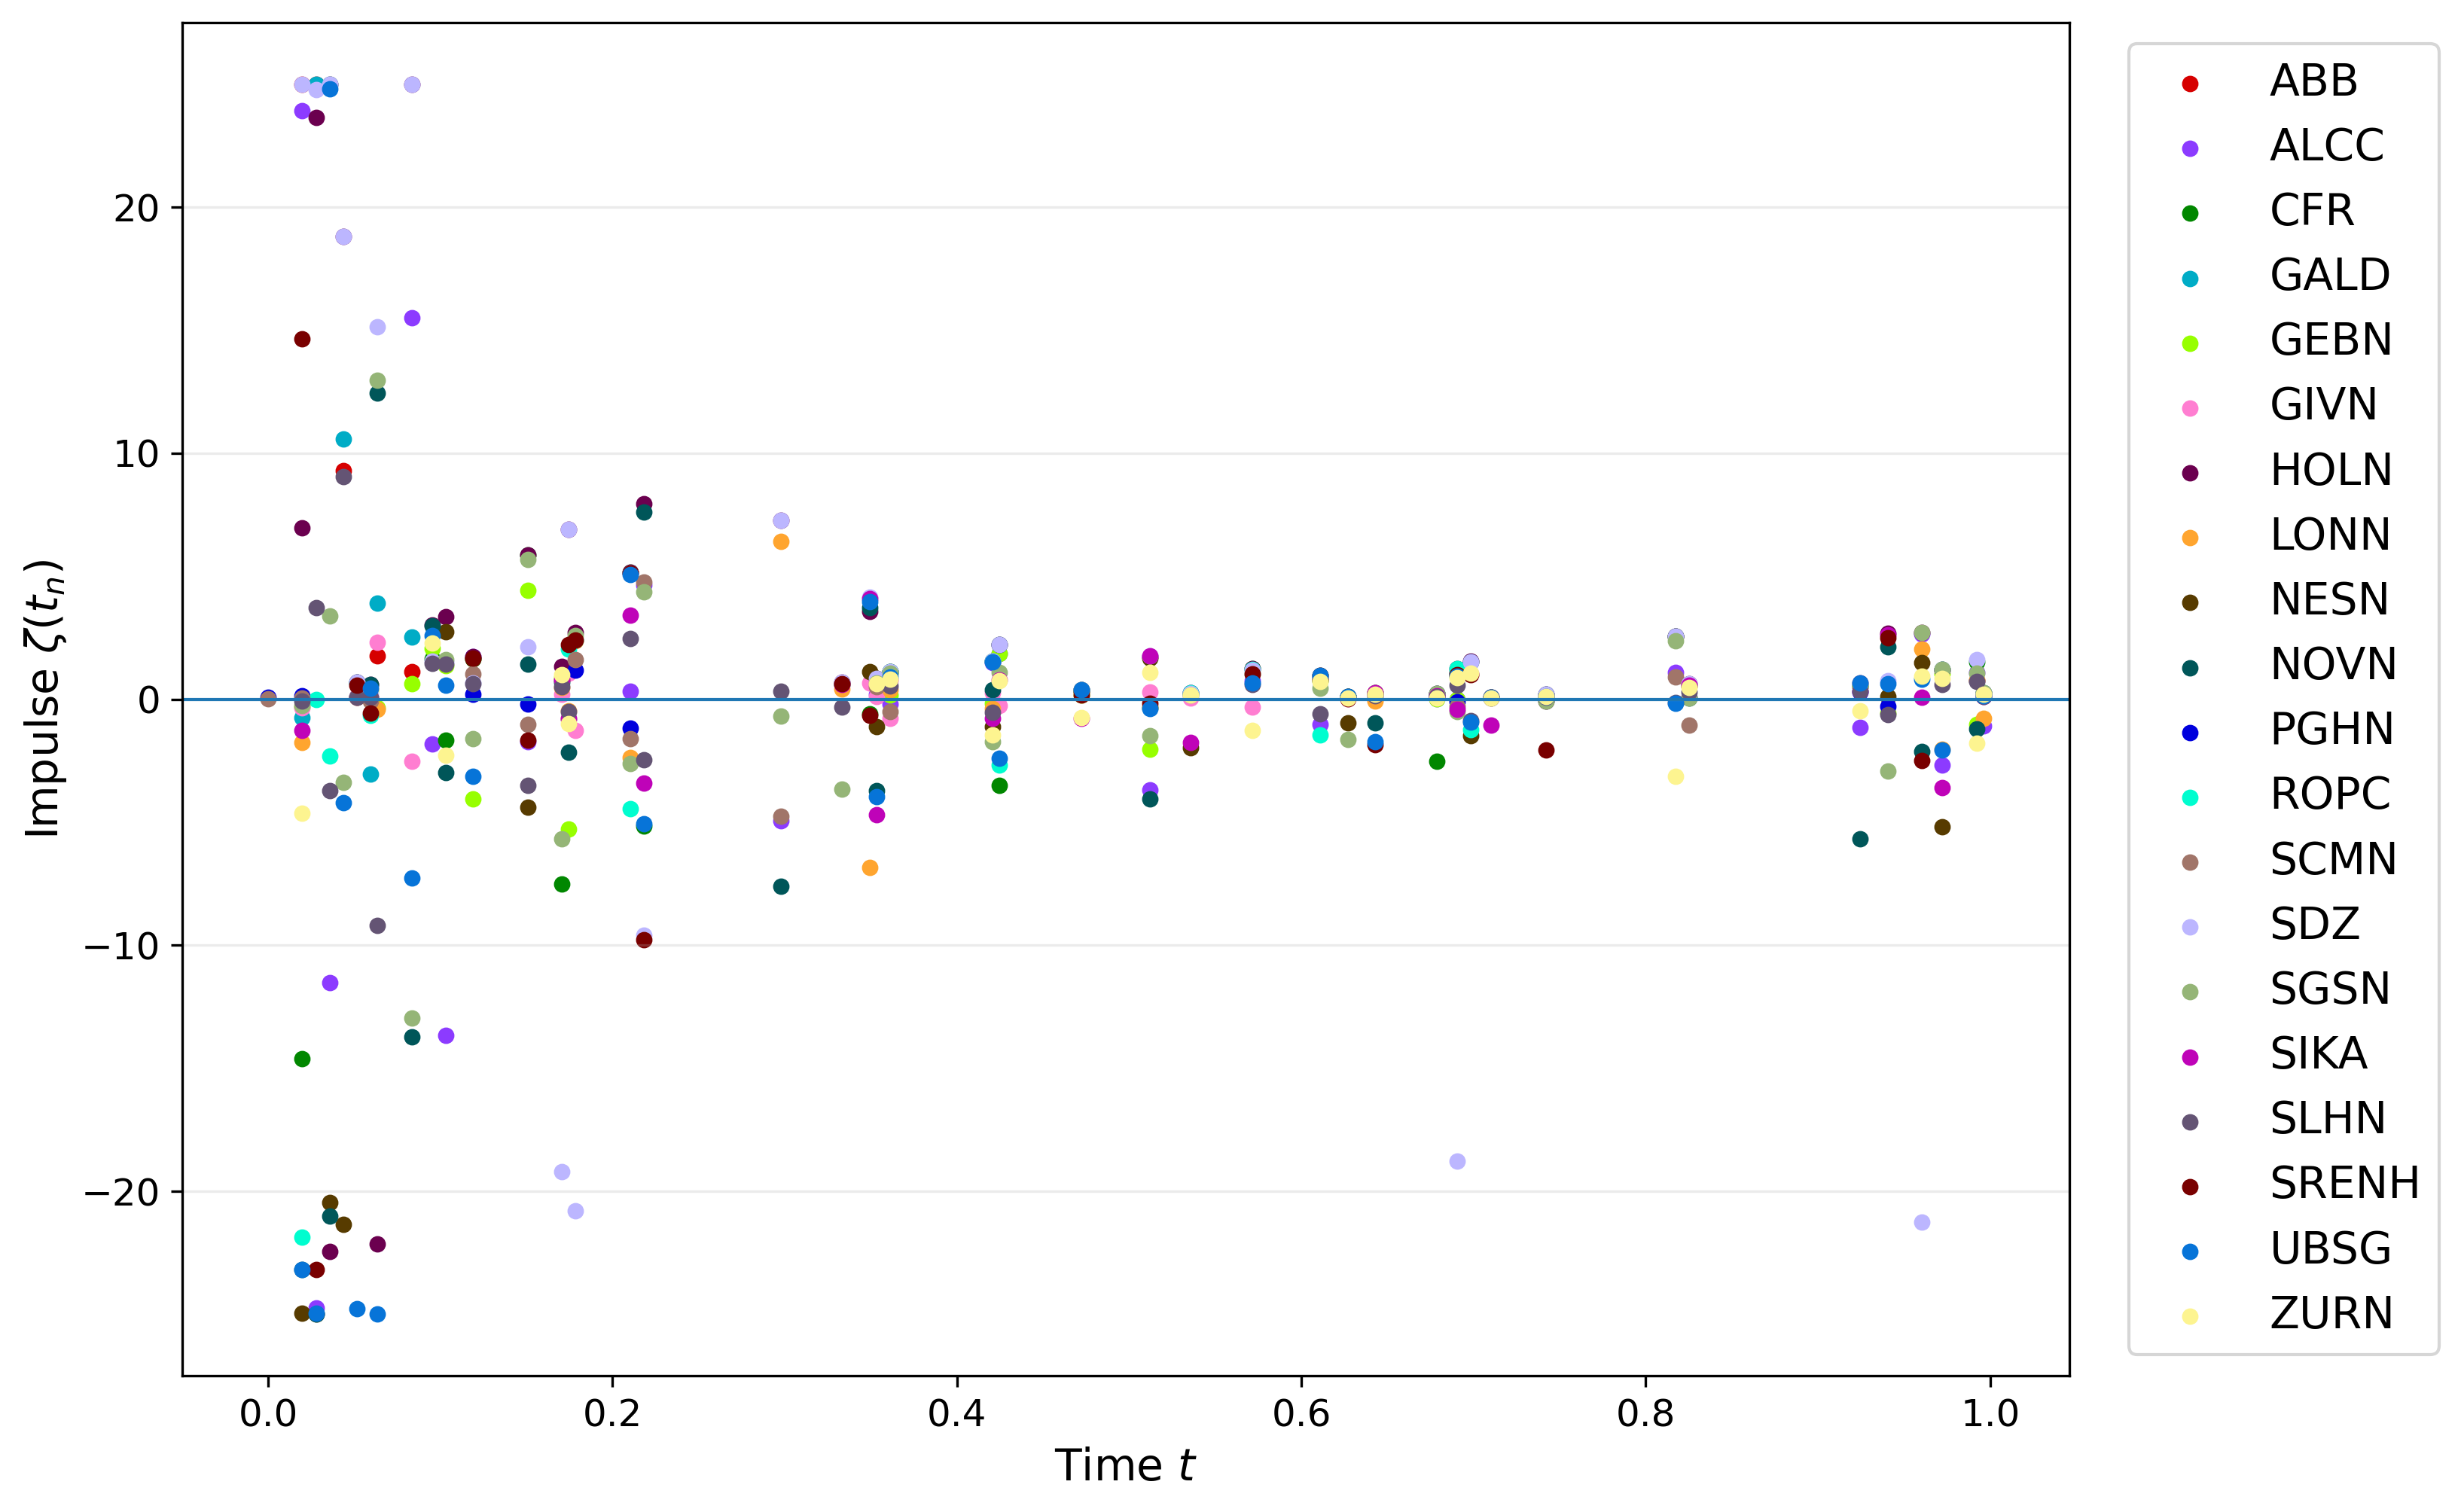

In [17]:
# One-path plot 4: PPO-SIL impulses through time.
one_trades = ppo_one_eval["trades"][0]
trade_time = time_grid[:-1]
trade_tolerance = 1.0e-8

plt.figure(figsize=(11, 7), dpi=300) #fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
any_impulses = False
for j, name in enumerate(asset_names):
    y = one_trades[:, j]
    nz = np.abs(y) > trade_tolerance
    any_impulses = any_impulses or bool(nz.any())
    plt.scatter(trade_time[nz], y[nz], s=18, label=name, color=asset_colors[name])
plt.axhline(0.0, linewidth=1.0)
if not any_impulses:
    plt.text(0.5, 0.5, "No impulses fired", transform=plt.gca().transAxes, ha="center", va="center")
#plt.title("One averaged path: PPO-SIL executed impulses")
plt.tick_params(axis="both", labelsize=12)
plt.xlabel(r'Time $t$', fontsize=14)
plt.ylabel(r'Impulse $\zeta(t_n)$', fontsize=14)
plt.grid(True, axis="y", alpha=0.25)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "one_path_ppo_sil_impulses.png", dpi=300, bbox_inches="tight")
plt.show()

## Tables and metrics

These metrics use the same Monte Carlo simulations as the average evaluation plots. Definitions:

- Excess return: terminal simple return minus the horizon risk-free return `exp(rT)-1`.
- Sharpe ratio: pathwise annualized Sharpe from step returns.
- Portfolio profit: terminal wealth minus initial wealth.
- Portfolio standard deviation: pathwise annualized standard deviation of step returns.

For return/profit/Sharpe, `Worst` is the minimum and `Best` is the maximum. For standard deviation, `Worst` is the maximum volatility and `Best` is the minimum volatility.

In [18]:
_NORMAL = NormalDist()


def _normal_cdf(x):
    return _NORMAL.cdf(float(x))


def _normal_ppf(p):
    p = min(max(float(p), 1.0e-12), 1.0 - 1.0e-12)
    return _NORMAL.inv_cdf(p)


def _safe_deflated_sharpe_from_returns(
    returns,
    *,
    risk_free_return=0.0,
    n_trials=1,
    sr_std_across_trials=0.0,
    eps=1.0e-12,
):
    r = np.asarray(returns, dtype=float).reshape(-1)
    r = r[np.isfinite(r)]

    if r.size < 3:
        return float("nan")

    excess = r - float(risk_free_return)
    mu = float(np.mean(excess))
    sig = float(np.std(excess, ddof=0))

    if not np.isfinite(sig) or sig <= float(eps):
        return float("nan")

    sr_hat = mu / sig  # non-annualized Sharpe
    z = (excess - mu) / sig

    skew_hat = float(np.mean(z ** 3))
    kurt_hat = float(np.mean(z ** 4))  # Pearson kurtosis; normal = 3

    n_trials = int(n_trials)
    sr_std_across_trials = float(sr_std_across_trials)

    if n_trials <= 1 or sr_std_across_trials <= float(eps):
        sr_0 = 0.0
    else:
        euler_gamma = 0.5772156649015329
        sr_0 = sr_std_across_trials * (
            (1.0 - euler_gamma) * _normal_ppf(1.0 - 1.0 / n_trials)
            + euler_gamma * _normal_ppf(1.0 - 1.0 / (n_trials * math.e))
        )

    denom_sq = (
        1.0
        - skew_hat * sr_hat
        + ((kurt_hat - 1.0) / 4.0) * sr_hat ** 2
    )

    if not np.isfinite(denom_sq) or denom_sq <= float(eps):
        return float("nan")

    z_score = (sr_hat - sr_0) * np.sqrt(r.size - 1.0) / np.sqrt(denom_sq)
    return float(_normal_cdf(z_score))


def pathwise_and_scalar_metrics(
    wealth,
    *,
    r,
    T,
    costs=None,
    trades=None,
    benchmark_wealth=None,
    n_strategy_trials=1,
    sr_std_across_trials=0.0,
):
    wealth = np.asarray(wealth, dtype=float)

    n_paths = wealth.shape[0]
    n_steps = max(wealth.shape[1] - 1, 1)
    dt = float(T) / n_steps
    annualization_factor = 1.0 / max(dt, 1.0e-12)

    init = np.maximum(wealth[:, 0], 1.0e-12)

    terminal_return = wealth[:, -1] / init - 1.0
    risk_free_horizon_return = math.exp(float(r) * float(T)) - 1.0
    excess_terminal_return = terminal_return - risk_free_horizon_return

    step_returns = safe_divide(wealth[:, 1:], wealth[:, :-1]) - 1.0
    risk_free_step_return = math.exp(float(r) * dt) - 1.0
    excess_step_returns = step_returns - risk_free_step_return

    step_mean_excess = np.nanmean(excess_step_returns, axis=1)
    step_std = np.nanstd(step_returns, axis=1, ddof=0)

    annualized_volatility = step_std * np.sqrt(annualization_factor)

    sharpe = np.full(n_paths, np.nan, dtype=float)
    ok_sharpe = np.isfinite(step_std) & (step_std > 1.0e-12)
    sharpe[ok_sharpe] = (
        np.sqrt(annualization_factor)
        * step_mean_excess[ok_sharpe]
        / step_std[ok_sharpe]
    )

    downside = np.minimum(excess_step_returns, 0.0)
    downside_deviation = np.sqrt(np.nanmean(downside ** 2, axis=1))

    sortino = np.full(n_paths, np.nan, dtype=float)
    ok_sortino = np.isfinite(downside_deviation) & (downside_deviation > 1.0e-12)
    sortino[ok_sortino] = (
        np.sqrt(annualization_factor)
        * step_mean_excess[ok_sortino]
        / downside_deviation[ok_sortino]
    )

    running_max = np.maximum.accumulate(wealth, axis=1)
    drawdown = safe_divide(wealth, running_max) - 1.0
    maximum_drawdown = np.nanmin(drawdown, axis=1)

    annualized_return = np.full(n_paths, np.nan, dtype=float)
    ok_ann_return = np.isfinite(terminal_return) & ((1.0 + terminal_return) > 0.0)
    annualized_return[ok_ann_return] = (
        (1.0 + terminal_return[ok_ann_return]) ** (1.0 / max(float(T), 1.0e-12))
        - 1.0
    )

    calmar = np.full(n_paths, np.nan, dtype=float)
    ok_calmar = np.isfinite(maximum_drawdown) & (np.abs(maximum_drawdown) > 1.0e-12)
    calmar[ok_calmar] = annualized_return[ok_calmar] / np.abs(maximum_drawdown[ok_calmar])

    if costs is None:
        total_transaction_cost = np.zeros(n_paths, dtype=float)
    else:
        costs = np.asarray(costs, dtype=float)
        total_transaction_cost = np.nansum(costs, axis=1)

    if trades is None:
        trade_count = np.zeros(n_paths, dtype=float)
    else:
        trades = np.asarray(trades, dtype=float)
        trade_count = np.sum(np.abs(trades).sum(axis=2) > 1.0e-12, axis=1).astype(float)

    finite_terminal_return = terminal_return[np.isfinite(terminal_return)]
    
    terminal_loss = init - wealth[:, -1]  # positive means loss, negative means profit
    finite_terminal_loss = terminal_loss[np.isfinite(terminal_loss)]
    if finite_terminal_loss.size > 0:
        var_5 = np.nanquantile(finite_terminal_loss, 0.95)
        cvar_5 = np.nanmean(finite_terminal_loss[finite_terminal_loss >= var_5])
        empirical_probability_of_loss = np.nanmean(finite_terminal_loss > 0.0)
    else:
        var_5 = np.nan
        cvar_5 = np.nan
        empirical_probability_of_loss = np.nan

    empirical_probability_outperform_bh = np.nan

    if benchmark_wealth is not None:
        benchmark_wealth = np.asarray(benchmark_wealth, dtype=float)
        benchmark_init = np.maximum(benchmark_wealth[:, 0], 1.0e-12)
        benchmark_terminal_return = benchmark_wealth[:, -1] / benchmark_init - 1.0
        empirical_probability_outperform_bh = np.nanmean(terminal_return > benchmark_terminal_return)

    deflated_sharpe_ratio = _safe_deflated_sharpe_from_returns(
        step_returns.reshape(-1),
        risk_free_return=risk_free_step_return,
        n_trials=n_strategy_trials,
        sr_std_across_trials=sr_std_across_trials,
    )

    path_metrics = {
        "Terminal return": terminal_return,
        "Excess terminal return": excess_terminal_return,
        "Annualized volatility": annualized_volatility,
        "Sharpe ratio": sharpe,
        "Sortino ratio": sortino,
        "Maximum drawdown": maximum_drawdown,
        "Calmar ratio": calmar,
        "Total transaction cost": total_transaction_cost,
        "Trade count": trade_count,
    }

    scalar_metrics = {
        "VaR 5%": var_5,
        "CVaR 5%": cvar_5,
        "Empirical probability of loss": empirical_probability_of_loss,
        "Empirical probability of outperforming buy-and-hold": empirical_probability_outperform_bh,
        "Deflated Sharpe ratio": deflated_sharpe_ratio,
    }

    return path_metrics, scalar_metrics

In [19]:
def summarize_metric(values, *, lower_is_better=False):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return {"Average": np.nan, "Worst": np.nan, "Best": np.nan}

    if lower_is_better:
        worst = np.nanmax(values)
        best = np.nanmin(values)
    else:
        worst = np.nanmin(values)
        best = np.nanmax(values)

    return {
        "Average": np.nanmean(values),
        "Worst": worst,
        "Best": best,
    }


LOWER_IS_BETTER = {
    "Annualized volatility": True,
    "Total transaction cost": True,
    "Trade count": True,
}


N_STRATEGY_TRIALS = 1
SR_STD_ACROSS_TRIALS = 0.0


strategy_inputs = {
    "PPO-SIL": {
        "wealth": ppo_avg_eval["wealth"],
        "costs": ppo_avg_eval["costs"],
        "trades": ppo_avg_eval["trades"],
        "benchmark_wealth": bh_avg_wealth,
    },
    "Buy-and-hold": {
        "wealth": bh_avg_wealth,
        "costs": None,
        "trades": None,
        "benchmark_wealth": None,
    },
}


rows = []

for strategy, inputs in strategy_inputs.items():
    path_metrics, scalar_metrics = pathwise_and_scalar_metrics(
        inputs["wealth"],
        r=float(eval_env.cfg.r),
        T=float(eval_env.cfg.T),
        costs=inputs["costs"],
        trades=inputs["trades"],
        benchmark_wealth=inputs["benchmark_wealth"],
        n_strategy_trials=N_STRATEGY_TRIALS,
        sr_std_across_trials=SR_STD_ACROSS_TRIALS,
    )

    for metric_name, values in path_metrics.items():
        summary = summarize_metric(
            values,
            lower_is_better=LOWER_IS_BETTER.get(metric_name, False),
        )
        rows.append({
            "Strategy": strategy,
            "Metric": metric_name,
            **summary,
        })

    for metric_name, value in scalar_metrics.items():
        rows.append({
            "Strategy": strategy,
            "Metric": metric_name,
            "Average": value,
            "Worst": np.nan,
            "Best": np.nan,
        })

metrics_table = pd.DataFrame(rows)
metrics_table

,Strategy,Metric,Average,Worst,Best
0,PPO-SIL,Terminal return,0.107760,-0.008624,0.254601
1,PPO-SIL,Excess terminal return,0.107760,-0.008624,0.254601
2,PPO-SIL,Annualized volatility,0.031585,0.042539,0.024462
3,PPO-SIL,Sharpe ratio,3.277393,-0.214078,8.180544
4,PPO-SIL,Sortino ratio,5.116431,-0.279439,17.268287
5,PPO-SIL,Maximum drawdown,-0.016992,-0.057835,-0.005423
6,PPO-SIL,Calmar ratio,7.520277,-0.246197,42.037339
7,PPO-SIL,Total transaction cost,217.921041,384.091258,119.782251
8,PPO-SIL,Trade count,50.204600,161.000000,29.000000
9,PPO-SIL,VaR 5%,-2579.914648,NaN,NaN


In [20]:
# Save the metrics table for later use.
metrics_csv_path = PLOTS_DIR / "evaluation_metrics_table.csv"
metrics_table.to_csv(metrics_csv_path, index=False)
print(f"Saved figures and metrics to: {PLOTS_DIR}")
print(f"Metrics table: {metrics_csv_path}")

Saved figures and metrics to: /Users/goshabor/NTNU/10.Semester/TMA4900 – Industriell matematikk, masteroppgave/Code/Experiment 2 – Dynamic portfolio allocation/SMI/MPS Code/Plots
Metrics table: /Users/goshabor/NTNU/10.Semester/TMA4900 – Industriell matematikk, masteroppgave/Code/Experiment 2 – Dynamic portfolio allocation/SMI/MPS Code/Plots/evaluation_metrics_table.csv


In [21]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df_terminal = pd.DataFrame({
    "TKR": asset_names,
    "S_T": one_prices[-1],
    "h_T": one_holdings[-1],
    'w_0': portfolio_weights_df['w']*100,
    'mu': FFT_estimates['mu'],
    "w_T": 100*(one_holdings[-1] * one_prices[-1]) / ppo_one_wealth[-1],
})

df_terminal#.sort_values(by=['w_T'], ascending=False)

,TKR,S_T,h_T,w_0,mu,w_T
0,ABB,105.79,133.00,7.58,0.13,24.13
1,ALCC,46.93,10.00,2.22,-0.08,0.80
2,CFR,163.65,5.98,5.52,0.00,1.68
3,GALD,181.96,69.00,1.81,0.19,21.53
4,GEBN,460.41,1.21,1.32,-0.01,0.96
5,GIVN,2583.17,0.00,1.88,-0.06,0.00
6,HOLN,92.67,122.07,2.47,0.13,19.40
7,LONN,505.08,1.00,2.61,0.01,0.87
8,NESN,77.31,6.00,15.05,-0.03,0.80
9,NOVN,119.75,4.25,17.12,0.06,0.87
